# Arabic Math Reasoning LLM 

###### Following *Build a Large Language Model (From Scratch)* by Sebastian Raschka

**Dataset**: [Omartificial-Intelligence-Space/Arabic-gsm8k-v2](https://huggingface.co/datasets/Omartificial-Intelligence-Space/Arabic-gsm8k-v2)

---

> **Project Summary:** In this notebook, I build a GPT model entirely from scratch using PyTorch.
> I trained it on an Arabic math word problem dataset (Arabic-gsm8k-v2) and walk through all 7 chapters of the book.


---

In [1]:
!nvidia-smi

Thu Mar 12 07:56:05 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# ============================================================
#  Install Dependencies
# ============================================================
!pip install -q torch datasets matplotlib seaborn plotly tqdm scikit-learn pandas gradio arabic-reshaper python-bidi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 26.8 MB/s eta 0:00:00


In [1]:
import os, sys, json, math, time, re, unicodedata
from pathlib import Path
from collections import Counter, defaultdict
from copy import deepcopy

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from tqdm.auto import tqdm

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'\U0001f4bb Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'   GPU: {torch.cuda.get_device_name()}')
    print(f'   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')


def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / 'README.md').exists():
        return cwd
    if cwd.name == 'notebooks' and (cwd.parent / 'README.md').exists():
        return cwd.parent
    return cwd


PROJECT_ROOT = resolve_project_root()
DATA_PRETRAIN_DIR = PROJECT_ROOT / 'data' / 'pretrain'
DATA_FINETUNE_DIR = PROJECT_ROOT / 'data' / 'finetune'
CHECKPOINTS_PRETRAIN_DIR = PROJECT_ROOT / 'checkpoints' / 'pretrained'
CHECKPOINTS_FINETUNE_DIR = PROJECT_ROOT / 'checkpoints' / 'finetuned'
RESULTS_SAMPLES_DIR = PROJECT_ROOT / 'results' / 'sample_generations'
RESULTS_PLOTS_DIR = PROJECT_ROOT / 'results' / 'plots'

for p in [
    DATA_PRETRAIN_DIR,
    DATA_FINETUNE_DIR,
    PROJECT_ROOT / 'src' / 'tokenizer',
    PROJECT_ROOT / 'src' / 'model',
    PROJECT_ROOT / 'src' / 'training',
    PROJECT_ROOT / 'src' / 'evaluation',
    PROJECT_ROOT / 'src' / 'demo',
    CHECKPOINTS_PRETRAIN_DIR,
    CHECKPOINTS_FINETUNE_DIR,
    RESULTS_SAMPLES_DIR,
    RESULTS_PLOTS_DIR,
    PROJECT_ROOT / 'notebooks',
]:
    p.mkdir(parents=True, exist_ok=True)

PRETRAIN_TEXT_PATH = DATA_PRETRAIN_DIR / 'data.txt'
SFT_DATA_PATH = DATA_FINETUNE_DIR / 'sft_data.json'
TOKENIZER_PATH = PROJECT_ROOT / 'data' / 'tokenizer.json'
BEST_PRETRAIN_PATH = CHECKPOINTS_PRETRAIN_DIR / 'best_pretrained.pt'
FINAL_PRETRAIN_PATH = CHECKPOINTS_PRETRAIN_DIR / 'final_pretrained.pt'
FINAL_SFT_PATH = CHECKPOINTS_FINETUNE_DIR / 'best_sft.pt'
SFT_SAMPLES_PATH = RESULTS_SAMPLES_DIR / 'sft_samples.json'

print(f'\U0001f4c1 Project root: {PROJECT_ROOT}')

import unicodedata
import re

_ARABIC_PRESENTATION_FORMS_RE = re.compile(r'[\uFB50-\uFDFF\uFE70-\uFEFF]')

def ar_text(text: str) -> str:
    # Normalize Arabic presentation forms to base characters for clean rendering.
    s = str(text).replace('\u200f', '').replace('\u200e', '')
    if _ARABIC_PRESENTATION_FORMS_RE.search(s):
        s = unicodedata.normalize('NFKC', s)
    return s


💻 Device: cuda
   GPU: Tesla T4
   Memory: 15.6 GB
📁 Project root: /content


---
# Chapter 1 — Understanding Large Language Models

| Concept | Explanation |
|---------|-------------|
| **Next-token prediction** | The model learns the probability of the next token given all previous tokens |
| **Tokens** | Sub-word units — the atoms the model operates on |
| **Embeddings** | Dense numerical representations for each token |
| **Transformer** | Architecture based on self-attention (Vaswani et al., 2017) |
| **GPT** | Decoder-only Transformer — generates text left-to-right |
| **Scaling laws** | More data + more parameters = better performance |

### Pipeline
```
Arabic math text → BPE encoding → Token IDs → Embeddings
→ Transformer blocks (attention + FFN + residual + layer norm)
→ Output logits → Next-token prediction → Generated solution
```

---
# Chapter 2 — Working With Text Data

**Key concepts:** Tokenization, vocabulary building, encoding/decoding, PyTorch Dataset & DataLoader, batching

> In this chapter, I converted Arabic text into numbers the model can understand.
> The first step is **tokenization**: splitting text into small units (tokens) and assigning an ID to each one.

---

## Step 2.1 — Download the Arabic GSM8K Dataset

> I downloaded the Arabic-gsm8k-v2 dataset from HuggingFace. It contains Arabic math word problems with step-by-step solutions.

In [4]:
from datasets import load_dataset

print('Downloading Omartificial-Intelligence-Space/Arabic-gsm8k-v2 ...')
ds = load_dataset('Omartificial-Intelligence-Space/Arabic-gsm8k-v2')

all_examples = []
for split in ds:
    for row in ds[split]:
        question = row.get('question', row.get('instruction', ''))
        answer = row.get('answer', row.get('output', ''))
        if question and answer:
            all_examples.append({'question': question, 'answer': answer})

print(f'Total examples: {len(all_examples)}')
print(f'\n--- Sample ---')
print(f"Question: {all_examples[0]['question'][:200]}")
print(f"Answer: {all_examples[0]['answer'][:200]}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/main_train-00000-of-00001.parquet:   0%|          | 0.00/5.77M [00:00<?, ?B/s]

data/main_test-00000-of-00001.parquet:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

data/socratic_train-00000-of-00001.parqu(…):   0%|          | 0.00/6.71M [00:00<?, ?B/s]

...

Generating main_train split:   0%|          | 0/7473 [00:00<?, ? examples/s]

Generating main_test split:   0%|          | 0/1319 [00:00<?, ? examples/s]

Generating socratic_train split:   0%|          | 0/7473 [00:00<?, ? examples/s]

Generating socratic_test split:   0%|          | 0/1319 [00:00<?, ? examples/s]

Total examples: 17584

--- Sample ---
Question: باعت نتاليا مشابك إلى 48 من أصدقائها في شهر أبريل، ثم باعت نصف ذلك العدد من المشابك في شهر مايو. كم عدد المشابك التي باعتها نتاليا في شهري أبريل ومايو معًا؟
Answer: باعت ناتاليا 48 ÷ 2 = <<48/2=24>>24 مشبكًا في مايو.
باعت ناتاليا 48 + 24 = <<48+24=72>>72 مشبكًا في أبريل ومايو مجتمعين.
#### 72


## Step 2.2 — Arabic Text Normalization

> Normalization unifies variant Arabic letter forms. For example: converting (إ, أ, آ) to (ا), and removing diacritics (Fatha, Damma, Kasra). This reduces vocabulary size and makes learning easier.

In [5]:
ARABIC_DIACRITICS = re.compile(r'[ؗ-ًؚ-ْٰ]')

def normalize_arabic(text: str, remove_diacritics: bool = True) -> str:
    text = unicodedata.normalize('NFKC', text)
    if remove_diacritics:
        text = ARABIC_DIACRITICS.sub('', text)
    text = re.sub(r'[إأآا]', 'ا', text)
    text = text.replace('ة', 'ه')
    return text

PRE_TOK_PATTERN = re.compile(
    r'[؀-ۿݐ-ݿﭐ-﷿ﹰ-﻿]+'
    r'|[0-9]+'
    r'|[^\s؀-ۿݐ-ݿﭐ-﷿ﹰ-﻿0-9]+'
)

def pre_tokenize(text: str) -> list:
    return PRE_TOK_PATTERN.findall(text)

sample = all_examples[0]['question']
print(f'Original:   {sample[:100]}')
print(f'Normalized:  {normalize_arabic(sample)[:100]}')
print(f'Words:       {pre_tokenize(normalize_arabic(sample))[:15]}')

Original:   باعت نتاليا مشابك إلى 48 من أصدقائها في شهر أبريل، ثم باعت نصف ذلك العدد من المشابك في شهر مايو. كم 
Normalized:  باعت نتاليا مشابك الى 48 من اصدقائها في شهر ابريل، ثم باعت نصف ذلك العدد من المشابك في شهر مايو. كم 
Words:       ['باعت', 'نتاليا', 'مشابك', 'الى', '48', 'من', 'اصدقائها', 'في', 'شهر', 'ابريل،', 'ثم', 'باعت', 'نصف', 'ذلك', 'العدد']


## Step 2.3 — BPE Tokenizer From Scratch

> **Byte-Pair Encoding (BPE):** An algorithm that iteratively merges the most frequent character pairs:
>
> ```
> 1. Start:    [ك, ت, ا, ب]              (individual characters)
> 2. Count:    (ت,ا)=200  (ك,ت)=100  (ا,ب)=150
> 3. Merge:    (ت,ا) → تا               (most frequent pair)
> 4. Result:   [ك, تا, ب]
> 5. Repeat until reaching target vocabulary size
> ```

In [6]:
class BPETokenizer:
    SPECIAL_TOKENS = {
        '<|pad|>': 0, '<|unk|>': 1, '<|bos|>': 2,
        '<|eos|>': 3, '<|im_start|>': 4, '<|im_end|>': 5,
    }

    def __init__(self, vocab_size=5000, remove_diacritics=True):
        self.target_vocab_size = vocab_size
        self.remove_diacritics = remove_diacritics
        self.merges = []
        self.vocab = {}
        self.inverse_vocab = {}
        self._trained = False

    def train(self, text, verbose=False):
        text = normalize_arabic(text, self.remove_diacritics)
        words = pre_tokenize(text)
        word_freqs = Counter(tuple(['▁'] + list(w)) for w in words)

        chars = set()
        for wt in word_freqs:
            chars.update(wt)

        self.vocab = dict(self.SPECIAL_TOKENS)
        idx = len(self.vocab)
        for ch in sorted(chars):
            if ch not in self.vocab:
                self.vocab[ch] = idx
                idx += 1

        num_merges = self.target_vocab_size - len(self.vocab)
        if num_merges <= 0:
            self._build_inverse()
            self._word_cache = {}
            self._trained = True
            return

        for i in tqdm(range(num_merges), desc='BPE merges', disable=not verbose):
            pair_counts = defaultdict(int)
            for wt, freq in word_freqs.items():
                for a, b in zip(wt, wt[1:]):
                    pair_counts[(a, b)] += freq
            if not pair_counts:
                break

            best = max(pair_counts, key=pair_counts.get)
            merged = best[0] + best[1]
            self.merges.append(best)
            self.vocab[merged] = idx
            idx += 1

            new_freqs = {}
            for wt, freq in word_freqs.items():
                new_w = []
                j = 0
                while j < len(wt):
                    if j < len(wt)-1 and wt[j]==best[0] and wt[j+1]==best[1]:
                        new_w.append(merged)
                        j += 2
                    else:
                        new_w.append(wt[j])
                        j += 1
                new_freqs[tuple(new_w)] = freq
            word_freqs = new_freqs

        self._build_inverse()
        self._word_cache = {}
        self._trained = True
        if verbose:
            print(f'Done. Vocab size: {len(self.vocab)}')

    def _apply_merge(self, tokens, pair):
        merged = pair[0] + pair[1]
        out = []
        i = 0
        while i < len(tokens):
            if i < len(tokens)-1 and tokens[i]==pair[0] and tokens[i+1]==pair[1]:
                out.append(merged)
                i += 2
            else:
                out.append(tokens[i])
                i += 1
        return out

    def _encode_word(self, word):
        if word in self._word_cache:
            return self._word_cache[word]
        tokens = ['▁'] + list(word)
        for pair in self.merges:
            tokens = self._apply_merge(tokens, pair)
        result = [self.vocab.get(tok, self.vocab['<|unk|>']) for tok in tokens]
        self._word_cache[word] = result
        return result

    def encode(self, text, add_special=False):
        if not hasattr(self, '_word_cache'):
            self._word_cache = {}
        text = normalize_arabic(text, self.remove_diacritics)
        words = pre_tokenize(text)
        ids = []
        if add_special:
            ids.append(self.vocab['<|bos|>'])
        for word in words:
            ids.extend(self._encode_word(word))
        if add_special:
            ids.append(self.vocab['<|eos|>'])
        return ids

    def decode(self, ids):
        pieces = []
        for i in ids:
            tok = self.inverse_vocab.get(i, '<|unk|>')
            if tok in self.SPECIAL_TOKENS:
                continue
            pieces.append(tok)

        text = ''.join(pieces)
        text = text.replace('▁', ' ').strip()
        # Clean spacing before punctuation.
        text = re.sub(r'\s+([،؟!?.,:;])', r'\1', text)
        return text

    @staticmethod
    def _merge_arabic(tokens):
        if not tokens:
            return ''
        arabic_re = re.compile(r'[؀-ۿ]')
        merged = [tokens[0]]
        for tok in tokens[1:]:
            if arabic_re.search(tok) and arabic_re.search(merged[-1]):
                merged[-1] += tok
            else:
                merged.append(tok)
        return ' '.join(merged)

    def get_token_details(self, text):
        text = normalize_arabic(text, self.remove_diacritics)
        words = pre_tokenize(text)
        details = []
        for word in words:
            tokens = ['▁'] + list(word)
            for pair in self.merges:
                tokens = self._apply_merge(tokens, pair)
            for tok in tokens:
                disp_tok = '␠' if tok == '▁' else tok
                details.append({'token': disp_tok, 'id': self.vocab.get(tok, 1), 'word': word})
        return details

    def _build_inverse(self):
        self.inverse_vocab = {v: k for k, v in self.vocab.items()}

    @property
    def vocab_size(self): return len(self.vocab)
    @property
    def pad_id(self): return 0
    @property
    def bos_id(self): return 2
    @property
    def eos_id(self): return 3

print('BPETokenizer class defined ✅')

BPETokenizer class defined ✅


## Step 2.4 — Prepare Data & Train Tokenizer

> I prepared two types of data: (1) raw text for pretraining, (2) instruction-answer pairs for fine-tuning. Then I trained the BPE tokenizer on the raw text.

In [7]:
pretrain_lines = []
for ex in all_examples:
    pretrain_lines.append(normalize_arabic(ex['question']))
    pretrain_lines.append(normalize_arabic(ex['answer']))
    pretrain_lines.append('')

pretrain_text = '\n'.join(pretrain_lines)
print(f'Pretraining text: {len(pretrain_text):,} chars, {len(pretrain_text.split()):,} words')

sft_records = []
for ex in all_examples:
    sft_records.append({
        'instruction': 'حل المساله الرياضيه التاليه خطوه بخطوه.',
        'input': ex['question'],
        'output': ex['answer'],
    })
print(f'Fine-tuning pairs: {len(sft_records):,}')

with open(PRETRAIN_TEXT_PATH, 'w', encoding='utf-8') as f:
    f.write(pretrain_text)
with open(SFT_DATA_PATH, 'w', encoding='utf-8') as f:
    json.dump(sft_records, f, ensure_ascii=False, indent=2)

VOCAB_SIZE = 5000
tokenizer = BPETokenizer(vocab_size=VOCAB_SIZE)
print(f'\nTraining tokenizer (vocab_size={VOCAB_SIZE})...')
tokenizer.train(pretrain_text, verbose=True)
print(f'Final vocab size: {tokenizer.vocab_size}')
print(f'Merges: {len(tokenizer.merges)}')

tokenizer_artifact = {
    'type': 'BPETokenizer',
    'vocab_size': tokenizer.vocab_size,
    'remove_diacritics': tokenizer.remove_diacritics,
    'special_tokens': tokenizer.SPECIAL_TOKENS,
    'vocab': tokenizer.vocab,
    'merges': tokenizer.merges,
}
with open(TOKENIZER_PATH, 'w', encoding='utf-8') as f:
    json.dump(tokenizer_artifact, f, ensure_ascii=False, indent=2)

print('\nSaved project artifacts:')
print(f'  - {PRETRAIN_TEXT_PATH}')
print(f'  - {SFT_DATA_PATH}')
print(f'  - {TOKENIZER_PATH}')

Pretraining text: 9,744,429 chars, 1,807,272 words
Fine-tuning pairs: 17,584

Training tokenizer (vocab_size=5000)...


BPE merges:   0%|          | 0/4810 [00:00<?, ?it/s]

Done. Vocab size: 5000
Final vocab size: 5000
Merges: 4810

Saved project artifacts:
  - /content/data/pretrain/data.txt
  - /content/data/finetune/sft_data.json
  - /content/data/tokenizer.json


## Visualize The Tokenization

> Visualizing the tokenizer splits the Arabic text into tokens. Each color represents a single token.

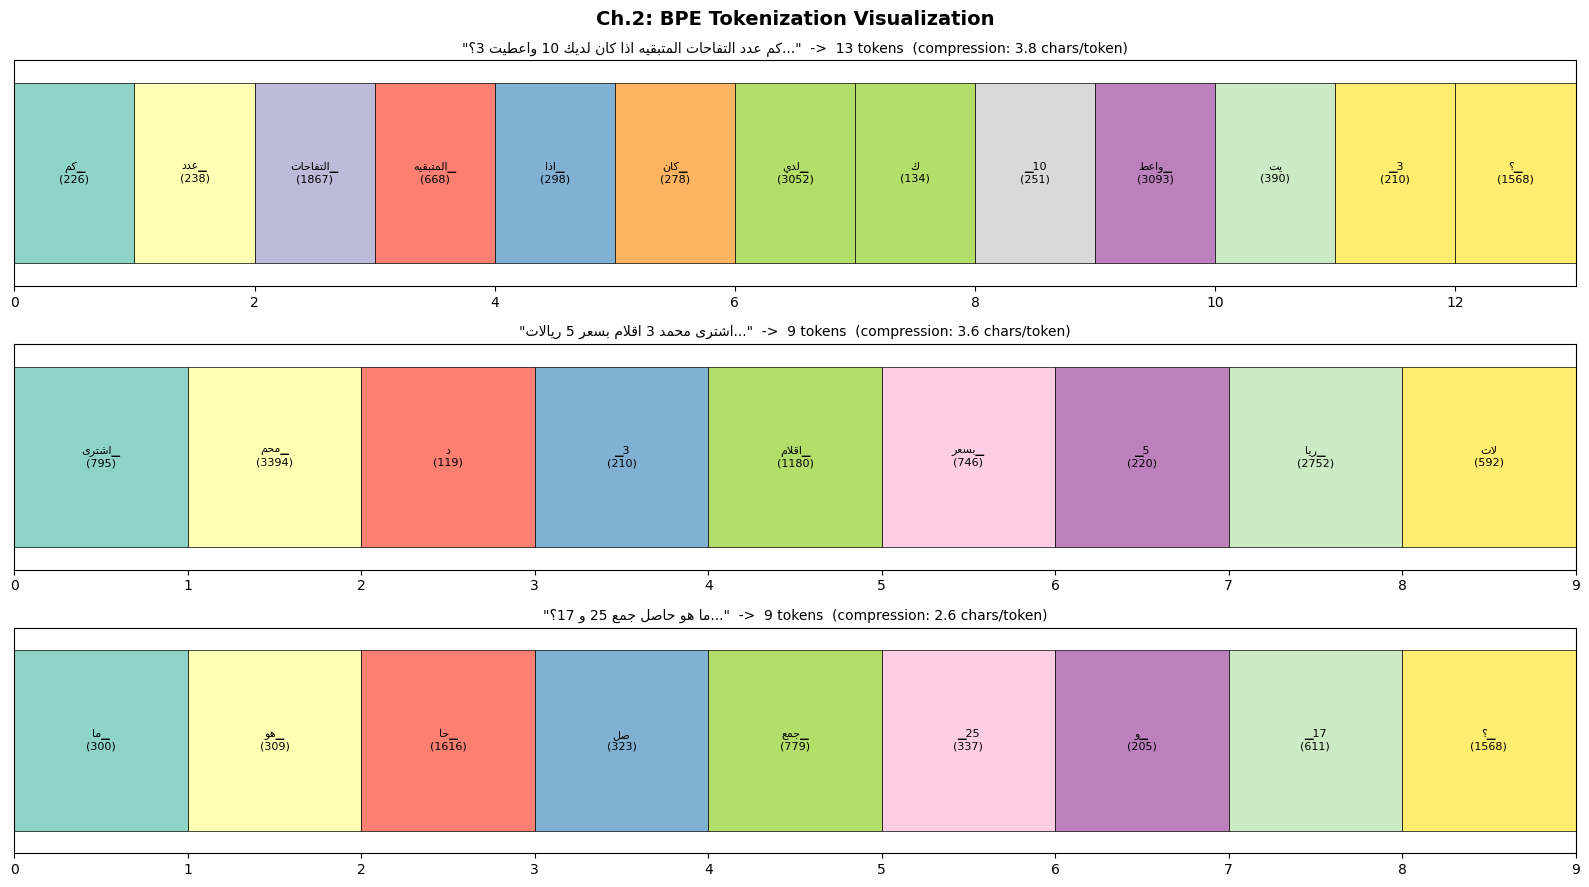

Original:  كم عدد التفاحات المتبقيه اذا كان لديك 10 واعطيت 3؟
Token IDs: [226, 238, 1867, 668, 298, 278, 3052, 134, 251, 3093, 390, 210, 1568]
Decoded:   كم عدد التفاحات المتبقيه اذا كان لديك 10 واعطيت 3؟

Original:  اشترى محمد 3 اقلام بسعر 5 ريالات
Token IDs: [795, 3394, 119, 210, 1180, 746, 220, 2752, 592]
Decoded:   اشترى محمد 3 اقلام بسعر 5 ريالات

Original:  ما هو حاصل جمع 25 و 17؟
Token IDs: [300, 309, 1616, 323, 779, 337, 205, 611, 1568]
Decoded:   ما هو حاصل جمع 25 و 17؟



In [8]:
test_sentences = [
    'كم عدد التفاحات المتبقيه اذا كان لديك 10 واعطيت 3؟',
    'اشترى محمد 3 اقلام بسعر 5 ريالات',
    'ما هو حاصل جمع 25 و 17؟',
]

fig, axes = plt.subplots(len(test_sentences), 1, figsize=(16, 3*len(test_sentences)))
for idx, sent in enumerate(test_sentences):
    details = tokenizer.get_token_details(sent)
    ids = tokenizer.encode(sent)
    colors = plt.cm.Set3(np.linspace(0, 1, len(details)))
    ax = axes[idx]
    for i, d in enumerate(details):
        ax.barh(0, 1, left=i, color=colors[i], edgecolor='black', linewidth=0.5)
        ax.text(i+0.5, 0, f"{ar_text(d['token'])}\n({d['id']})", ha='center', va='center', fontsize=8)
    ax.set_xlim(0, len(details))
    ax.set_ylim(-0.5, 0.5)
    ax.set_yticks([])
    ax.set_title(f'"{ar_text(sent[:60])}..."  ->  {len(ids)} tokens  (compression: {len(sent)/len(ids):.1f} chars/token)', fontsize=10)

plt.suptitle('Ch.2: BPE Tokenization Visualization', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

for sent in test_sentences:
    ids = tokenizer.encode(sent)
    decoded = tokenizer.decode(ids)
    print(f'Original:  {sent}')
    print(f'Token IDs: {ids}')
    print(f'Decoded:   {decoded}\n')

## Step 2.5 — PyTorch Dataset & DataLoader

> I split the text into sliding windows of length `context_length + 1`. Input = tokens[:-1] and target = tokens[1:] (next-token prediction).

In [9]:
CONTEXT_LENGTH = 256

class PretrainDataset(Dataset):
    def __init__(self, text, tokenizer, context_length=256, stride=128):
        print('Encoding text... (may take ~1 minute)')
        self.token_ids = tokenizer.encode(text)
        print(f'Encoded: {len(self.token_ids):,} tokens')
        self.samples = []
        for i in range(0, len(self.token_ids) - context_length, stride):
            chunk = self.token_ids[i : i + context_length + 1]
            self.samples.append(torch.tensor(chunk, dtype=torch.long))
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        c = self.samples[idx]
        return c[:-1], c[1:]

class SFTDataset(Dataset):
    def __init__(self, records, tokenizer, context_length=256):
        self.samples, self.loss_masks = [], []
        im_s, im_e = tokenizer.bos_id, tokenizer.eos_id
        print(f'Preparing {len(records):,} SFT samples...')
        for rec in tqdm(records, desc='SFT data'):
            prompt = f"{rec['instruction']}\n{rec.get('input', '')}"
            prompt_ids = [im_s] + tokenizer.encode(prompt) + [im_e]
            resp_ids   = [im_s] + tokenizer.encode(rec['output']) + [im_e]
            full = prompt_ids + resp_ids
            if len(full) > context_length + 1:
                full = full[:context_length + 1]
                plen = min(len(prompt_ids), context_length + 1)
            else:
                plen = len(prompt_ids)
                full += [tokenizer.pad_id] * (context_length + 1 - len(full))
            mask = [0]*plen + [1]*(len(full)-plen)
            for i in range(len(full)):
                if full[i] == tokenizer.pad_id: mask[i] = 0
            self.samples.append(torch.tensor(full, dtype=torch.long))
            self.loss_masks.append(torch.tensor(mask[:context_length+1], dtype=torch.float))
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        c, m = self.samples[idx], self.loss_masks[idx]
        return c[:-1], c[1:], m[1:]

pretrain_dataset = PretrainDataset(pretrain_text, tokenizer, CONTEXT_LENGTH, stride=128)
val_size = max(1, int(0.1 * len(pretrain_dataset)))
train_size = len(pretrain_dataset) - val_size
train_ds, val_ds = random_split(pretrain_dataset, [train_size, val_size])

BATCH_SIZE = 16
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

print(f'Pretrain dataset: {len(pretrain_dataset):,} samples')
print(f'  Train: {train_size:,} | Val: {val_size:,}')

inp, tgt = next(iter(train_loader))
print(f'\nBatch shape: Input {inp.shape} | Target {tgt.shape}')
print(f'Note: target is shifted by 1 position (next-token prediction)')

Encoding text... (may take ~1 minute)
Encoded: 2,860,062 tokens
Pretrain dataset: 22,343 samples
  Train: 20,109 | Val: 2,234

Batch shape: Input torch.Size([16, 256]) | Target torch.Size([16, 256])
Note: target is shifted by 1 position (next-token prediction)


---
# Chapter 3 — Coding Attention Mechanisms

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

> **Self-attention** is the heart of the Transformer. It allows each token to look at all previous tokens and determine which are most important.
>
> - **Q (Query)**: What am I looking for?
> - **K (Key)**: What do I contain?
> - **V (Value)**: What information do I provide?
>
> **Causal mask**: Prevents tokens from looking into the future (essential for generation).

---

In [10]:
def scaled_dot_product_attention(query, key, value, mask=None, dropout=None):
    d_k = query.size(-1)
    scores = torch.matmul(query, key.transpose(-2, -1)) / math.sqrt(d_k)
    if mask is not None:
        scores = scores.masked_fill(mask == 0, float('-inf'))
    weights = torch.softmax(scores, dim=-1)
    if dropout is not None:
        weights = dropout(weights)
    return torch.matmul(weights, value), weights

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads, context_length, dropout=0.0):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model, self.n_heads = d_model, n_heads
        self.d_k = d_model // n_heads
        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.out_proj = nn.Linear(d_model, d_model, bias=False)
        self.dropout = nn.Dropout(dropout)
        mask = torch.tril(torch.ones(context_length, context_length))
        self.register_buffer('mask', mask.unsqueeze(0).unsqueeze(0))

    def forward(self, x, return_attention=False):
        B, T, C = x.shape
        q = self.W_q(x).view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        k = self.W_k(x).view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        v = self.W_v(x).view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        ctx, attn_w = scaled_dot_product_attention(q, k, v, mask=self.mask[:,:,:T,:T], dropout=self.dropout)
        ctx = ctx.transpose(1, 2).contiguous().view(B, T, self.d_model)
        out = self.out_proj(ctx)
        return (out, attn_w) if return_attention else out

print('Attention classes defined ✅')

Attention classes defined ✅


## Visualize: How Attention Works Step by Step

> We'll see the four steps: (1) Compute scores QK^T/√d_k, (2) Apply causal mask, (3) Softmax, (4) Weighted sum.

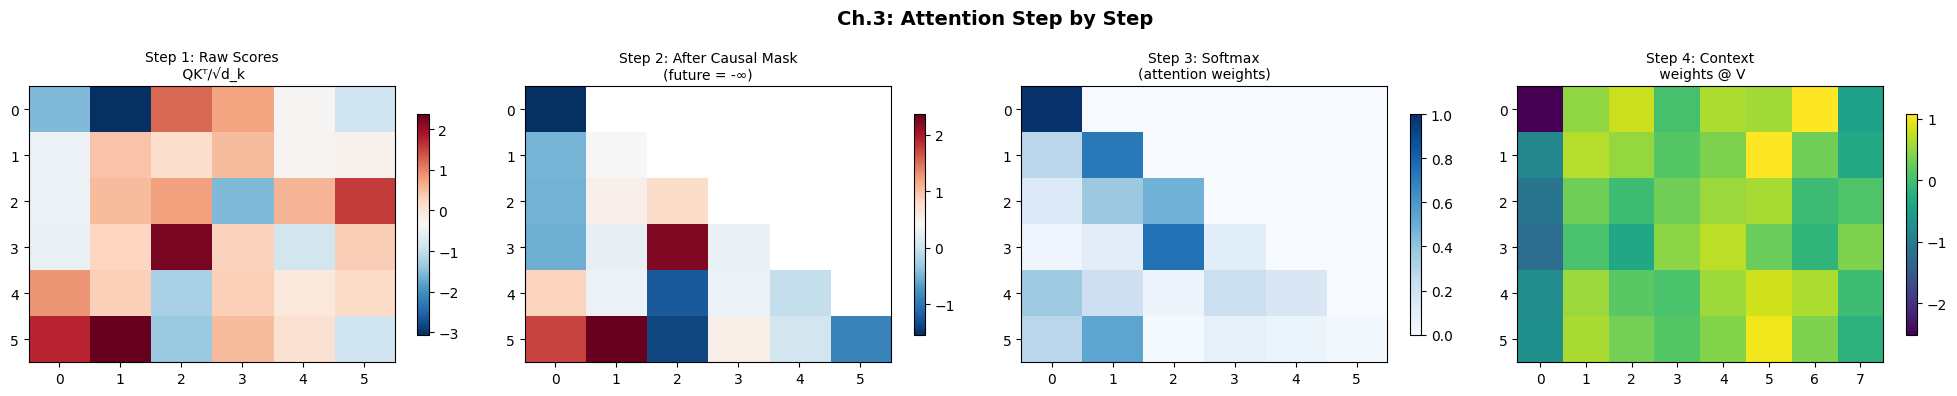

✔ Each row in step 3 sums to 1 (probability distribution)
✔ Upper triangle is zero (causal mask prevents looking ahead)


In [11]:
torch.manual_seed(42)
seq_len, d_k = 6, 8
Q = torch.randn(1, 1, seq_len, d_k)
K = torch.randn(1, 1, seq_len, d_k)
V = torch.randn(1, 1, seq_len, d_k)

raw_scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)
causal = torch.tril(torch.ones(seq_len, seq_len)).unsqueeze(0).unsqueeze(0)
masked_scores = raw_scores.masked_fill(causal == 0, float('-inf'))
attn_weights = torch.softmax(masked_scores, dim=-1)
context, _ = scaled_dot_product_attention(Q, K, V, mask=causal)

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
titles = ['Step 1: Raw Scores\n QKᵀ/√d_k', 'Step 2: After Causal Mask\n(future = -∞)',
          'Step 3: Softmax\n(attention weights)', 'Step 4: Context\n weights @ V']
data = [raw_scores[0,0], masked_scores[0,0], attn_weights[0,0], context[0,0,:,:d_k]]
cmaps = ['RdBu_r', 'RdBu_r', 'Blues', 'viridis']
for ax, d, t, cm in zip(axes, data, titles, cmaps):
    im = ax.imshow(d.detach().numpy(), cmap=cm, aspect='auto')
    ax.set_title(t, fontsize=10)
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle('Ch.3: Attention Step by Step', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('✔ Each row in step 3 sums to 1 (probability distribution)')
print('✔ Upper triangle is zero (causal mask prevents looking ahead)')

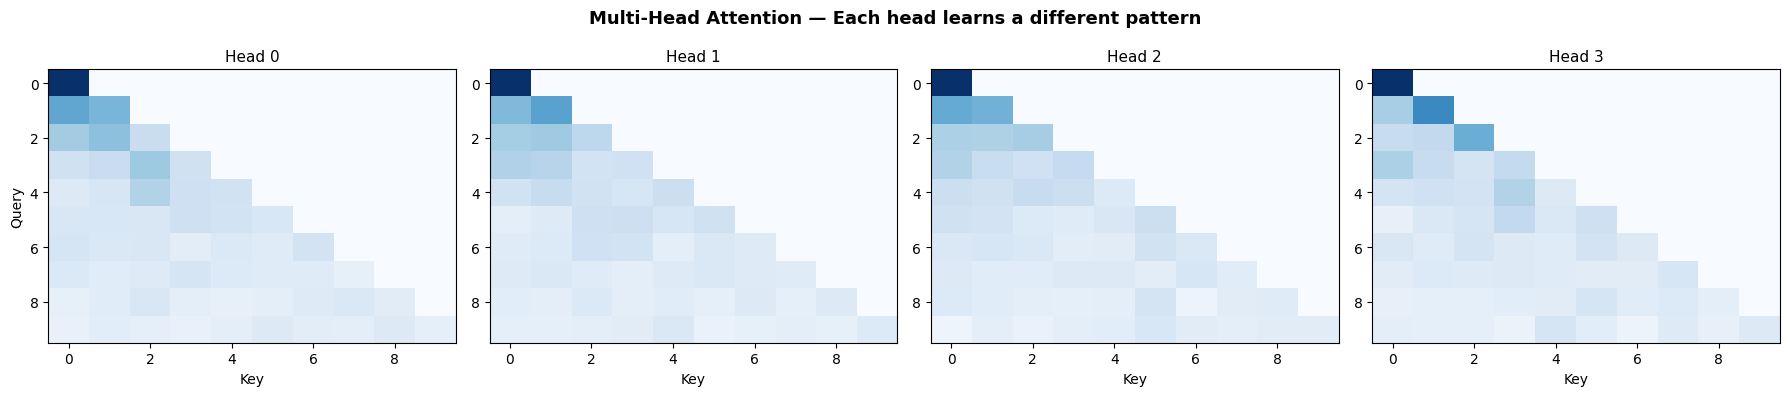

Input: torch.Size([1, 10, 64]) → Output: torch.Size([1, 10, 64]) (same shape = ready for residual connections)


In [12]:
mha = MultiHeadAttention(d_model=64, n_heads=4, context_length=20)
x = torch.randn(1, 10, 64)
out, attn_w = mha(x, return_attention=True)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for h in range(4):
    axes[h].imshow(attn_w[0, h].detach().numpy(), cmap='Blues', aspect='auto')
    axes[h].set_title(f'Head {h}', fontsize=11)
    axes[h].set_xlabel('Key')
    if h == 0: axes[h].set_ylabel('Query')

plt.suptitle('Multi-Head Attention — Each head learns a different pattern', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Input: {x.shape} → Output: {out.shape} (same shape = ready for residual connections)')

---
# Chapter 4 — Implementing a GPT Model From Scratch

> **Components:** Token embedding + positional embedding → N Transformer blocks → Layer norm → Output head
>
> **Residual connections:** Prevent vanishing gradients and enable deeper training.
> **Weight tying:** The embedding matrix and output head share the same weights.

---

In [13]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim, eps=1e-5):
        super().__init__()
        self.eps = eps
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))
    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        return self.scale * (x - mean) / torch.sqrt(var + self.eps) + self.shift

class GELU(nn.Module):
    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh((2/torch.pi)**0.5 * (x + 0.044715 * x**3)))

class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg['emb_dim'], 4 * cfg['emb_dim']), GELU(),
            nn.Linear(4 * cfg['emb_dim'], cfg['emb_dim']), nn.Dropout(cfg['drop_rate']))
    def forward(self, x): return self.layers(x)

class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.ln1 = LayerNorm(cfg['emb_dim'])
        self.attn = MultiHeadAttention(cfg['emb_dim'], cfg['n_heads'], cfg['context_length'], cfg['drop_rate'])
        self.ln2 = LayerNorm(cfg['emb_dim'])
        self.ffn = FeedForward(cfg)
    def forward(self, x, return_attention=False):
        if return_attention:
            ao, aw = self.attn(self.ln1(x), return_attention=True)
            x = x + ao
        else:
            x = x + self.attn(self.ln1(x))
        x = x + self.ffn(self.ln2(x))
        return (x, aw) if return_attention else x

class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.tok_emb = nn.Embedding(cfg['vocab_size'], cfg['emb_dim'])
        self.pos_emb = nn.Embedding(cfg['context_length'], cfg['emb_dim'])
        self.drop_emb = nn.Dropout(cfg['drop_rate'])
        self.trf_blocks = nn.ModuleList([TransformerBlock(cfg) for _ in range(cfg['n_layers'])])
        self.final_norm = LayerNorm(cfg['emb_dim'])
        self.out_head = nn.Linear(cfg['emb_dim'], cfg['vocab_size'], bias=False)
        self.out_head.weight = self.tok_emb.weight
        self._init_weights()
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Embedding):
                nn.init.normal_(m.weight, 0, 0.02)
    def forward(self, idx, return_attention=False):
        B, T = idx.shape
        x = self.drop_emb(self.tok_emb(idx) + self.pos_emb(torch.arange(T, device=idx.device)))
        attn_maps = []
        for block in self.trf_blocks:
            if return_attention:
                x, aw = block(x, return_attention=True); attn_maps.append(aw)
            else:
                x = block(x)
        logits = self.out_head(self.final_norm(x))
        return (logits, attn_maps) if return_attention else logits
    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

print('GPT model defined ✅')

GPT model defined ✅


In [14]:
GPT_CONFIG = {
    'vocab_size': tokenizer.vocab_size, 'context_length': CONTEXT_LENGTH,
    'emb_dim': 512, 'n_heads': 8, 'n_layers': 6, 'drop_rate': 0.1,
}
model = GPTModel(GPT_CONFIG).to(DEVICE)

print('=== Model Configuration ===')
for k, v in GPT_CONFIG.items():
    print(f'  {k}: {v}')
print(f'\n  Total parameters: {model.count_parameters():,}')
print(f'  Device: {DEVICE}')

=== Model Configuration ===
  vocab_size: 5000
  context_length: 256
  emb_dim: 512
  n_heads: 8
  n_layers: 6
  drop_rate: 0.1

  Total parameters: 21,594,112
  Device: cuda


## Visualize: Embeddings & Architecture

> Let's see how the model converts tokens into dense vectors. Token embedding + positional embedding = model input.

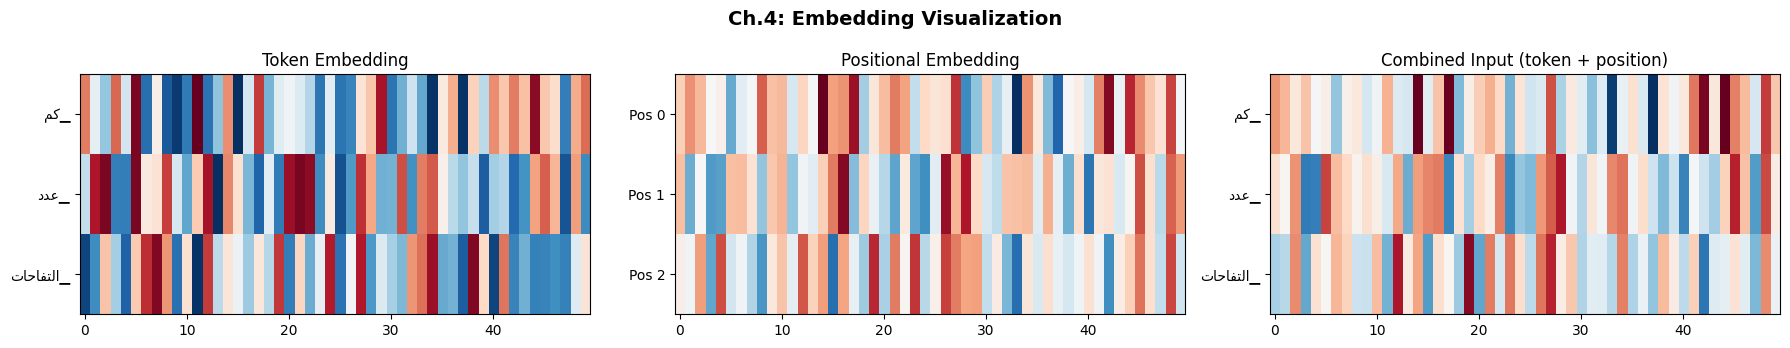

Input: "كم عدد التفاحات" → 3 tokens
Output shape: torch.Size([1, 3, 5000])

Predictions (untrained model = random):
  "▁83" → p=0.0011
  "▁توبي" → p=0.0009
  "▁ن" → p=0.0008
  "▁غالونات" → p=0.0007
  "غار" → p=0.0007


In [15]:
sample_text = 'كم عدد التفاحات'
sample_ids = tokenizer.encode(sample_text)
sample_tensor = torch.tensor([sample_ids], device=DEVICE)

with torch.no_grad():
    tok_emb = model.tok_emb(sample_tensor).cpu()
    pos_emb = model.pos_emb(torch.arange(len(sample_ids), device=DEVICE)).cpu()
    combined = tok_emb[0] + pos_emb

details = tokenizer.get_token_details(sample_text)
labels = [ar_text(d['token']) for d in details]

fig, axes = plt.subplots(1, 3, figsize=(18, 3.5))
axes[0].imshow(tok_emb[0].numpy()[:, :50], cmap='RdBu', aspect='auto')
axes[0].set_yticks(range(len(labels))); axes[0].set_yticklabels(labels)
axes[0].set_title('Token Embedding')
axes[1].imshow(pos_emb.numpy()[:, :50], cmap='RdBu', aspect='auto')
axes[1].set_yticks(range(len(labels))); axes[1].set_yticklabels([f'Pos {i}' for i in range(len(labels))])
axes[1].set_title('Positional Embedding')
axes[2].imshow(combined.numpy()[:, :50], cmap='RdBu', aspect='auto')
axes[2].set_yticks(range(len(labels))); axes[2].set_yticklabels(labels)
axes[2].set_title('Combined Input (token + position)')
plt.suptitle('Ch.4: Embedding Visualization', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

with torch.no_grad():
    logits, _ = model(sample_tensor, return_attention=True)
probs = torch.softmax(logits[0, -1, :], dim=-1)
top5_p, top5_i = torch.topk(probs, 5)
print(f'Input: "{sample_text}" → {len(sample_ids)} tokens')
print(f'Output shape: {logits.shape}')
print(f'\nPredictions (untrained model = random):')
for p, i in zip(top5_p, top5_i):
    print(f'  "{tokenizer.inverse_vocab.get(i.item(), "?")}" → p={p.item():.4f}')

---
# Chapter 5 — Pretraining on Unlabeled Data

> The model learns **next-token prediction** without any labels. The text itself is the teacher
>
> **Loss function**: Cross-Entropy — measures the gap between the model's distribution and the correct token.
> **Optimizer**: AdamW with cosine learning rate schedule and linear warmup.

---

In [16]:
def generate(model, idx, max_new_tokens, context_length, temperature=1.0, top_k=None, eos_id=None):
    model.eval()
    with torch.no_grad():
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -context_length:]
            logits = model(idx_cond)[:, -1, :]
            if temperature != 1.0: logits = logits / temperature
            if top_k is not None:
                tv, _ = torch.topk(logits, top_k)
                logits = torch.where(logits < tv[:, -1:], torch.full_like(logits, float('-inf')), logits)
            probs = torch.softmax(logits, dim=-1)
            next_tok = torch.multinomial(probs, 1)
            idx = torch.cat([idx, next_tok], dim=-1)
            if eos_id is not None and (next_tok == eos_id).all(): break
    return idx

def calc_loss_batch(model, inp, tgt, device):
    inp, tgt = inp.to(device), tgt.to(device)
    logits = model(inp)
    return nn.functional.cross_entropy(logits.view(-1, logits.size(-1)), tgt.view(-1))

def calc_loss_loader(model, loader, device, max_batches=None):
    model.eval()
    total, n = 0.0, 0
    with torch.no_grad():
        for i, (inp, tgt) in enumerate(loader):
            if max_batches and i >= max_batches: break
            total += calc_loss_batch(model, inp, tgt, device).item(); n += 1
    model.train()
    return total / max(n, 1)

def cosine_lr(optimizer, step, total_steps, lr_max, lr_min=1e-6, warmup=100):
    if step < warmup: lr = lr_max * step / max(warmup, 1)
    else:
        progress = (step - warmup) / max(total_steps - warmup, 1)
        lr = lr_min + 0.5 * (lr_max - lr_min) * (1 + math.cos(math.pi * progress))
    for pg in optimizer.param_groups: pg['lr'] = lr
    return lr

init_loss = calc_loss_loader(model, val_loader, DEVICE, max_batches=5)
print(f'Initial loss:          {init_loss:.4f}')
print(f'Expected random loss:  {math.log(tokenizer.vocab_size):.4f}  (ln(vocab_size))')
print(f'Initial perplexity:    {math.exp(init_loss):.0f}')

Initial loss:          8.6134
Expected random loss:  8.5172  (ln(vocab_size))
Initial perplexity:    5505


## Step 5.1 — Run Pretraining

> Now we train the model on Arabic text. We monitor the loss and generate samples during training.

In [17]:
NUM_EPOCHS = 10
LR = 5e-4
GRAD_CLIP = 1.0
LOG_EVERY, EVAL_EVERY, SAMPLE_EVERY = 50, 200, 300

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.1)
total_steps = NUM_EPOCHS * len(train_loader)
warmup_steps = min(100, total_steps // 10)

history = {'train_loss': [], 'val_loss': [], 'lr': [], 'step': [], 'samples': []}
model.train()
global_step = 0
best_val = float('inf')
t0 = time.time()

print(f'\n{"="*60}')
print(f'  Pretraining — {model.count_parameters():,} parameters')
print(f'  Device: {DEVICE}  |  Epochs: {NUM_EPOCHS}  |  Steps: {total_steps}')
print(f'{"="*60}\n')

for epoch in range(NUM_EPOCHS):
    pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{NUM_EPOCHS}', leave=True)
    for inp, tgt in pbar:
        lr = cosine_lr(optimizer, global_step, total_steps, LR, warmup=warmup_steps)
        loss = calc_loss_batch(model, inp, tgt, DEVICE)
        optimizer.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step(); global_step += 1
        pbar.set_postfix(loss=f'{loss.item():.4f}', lr=f'{lr:.2e}')
        if global_step % LOG_EVERY == 0:
            history['train_loss'].append(loss.item()); history['lr'].append(lr); history['step'].append(global_step)
        if global_step % EVAL_EVERY == 0:
            vl = calc_loss_loader(model, val_loader, DEVICE, max_batches=20)
            history['val_loss'].append(vl); model.train()
            if vl < best_val:
                best_val = vl
                torch.save(
                    {
                        'model_state_dict': model.state_dict(),
                        'config': GPT_CONFIG,
                        'step': global_step,
                        'val_loss': vl,
                    },
                    BEST_PRETRAIN_PATH,
                )
            tqdm.write(f'  Step {global_step} | val_loss: {vl:.4f} | best: {best_val:.4f}')
        if global_step % SAMPLE_EVERY == 0:
            sample_prompt_ids = tokenizer.encode('حل المساله')
            gen = generate(model, torch.tensor([sample_prompt_ids], device=DEVICE),
                           max_new_tokens=50, context_length=CONTEXT_LENGTH, temperature=0.8, top_k=25)
            txt = tokenizer.decode(gen[0].tolist()[len(sample_prompt_ids):])
            history['samples'].append({'step': global_step, 'text': txt})
            tqdm.write(f'  ✍️  {txt[:120]}'); model.train()

torch.save(
    {
        'model_state_dict': model.state_dict(),
        'config': GPT_CONFIG,
        'step': global_step,
        'val_loss': best_val,
    },
    FINAL_PRETRAIN_PATH,
)

print(f'\n✅ Pretraining done in {time.time()-t0:.0f}s | Best val loss: {best_val:.4f}')
print(f'Saved best checkpoint:  {BEST_PRETRAIN_PATH}')
print(f'Saved final checkpoint: {FINAL_PRETRAIN_PATH}')


  Pretraining — 21,594,112 parameters
  Device: cuda  |  Epochs: 10  |  Steps: 12560



Epoch 1/10:   0%|          | 0/1256 [00:00<?, ?it/s]

  Step 200 | val_loss: 5.7902 | best: 5.7902
  ✍️  ؟ ** في الاسبوع؟ ** اذا كان مجموع عدد المار، اذا كان هناك 40 / 4 - 2 = 10 >> 8 = << 4 + 5 * 10 = << 12 >> 18 >> 18 >> 60
  Step 400 | val_loss: 5.1445 | best: 5.1445
  Step 600 | val_loss: 4.6489 | best: 4.6489
  ✍️  . كم عدد الاسماك التي تملكها ماري في كل طالب في كل قطعه من كل قطعه من الحليب؟ بكم عدد الاسماك في رحله تلاحظات في كل شهر 
  Step 800 | val_loss: 4.2655 | best: 4.2655
  ✍️  في حفل التخفيه. ما مجموعه الرخت من السبوا. في هذه الرتار. اذا كان عدد الاقق الذين يتقن في حفل التخت الذين يقطوا في حفل ا
  Step 1000 | val_loss: 3.9734 | best: 3.9734
  Step 1200 | val_loss: 3.7065 | best: 3.7065
  ✍️  ين: 4 ارانب / شخص * 4 اطارات = << 4 * 4 = 8 >> 8 هكرين. يبلغ مجموع اقاه الاجمالي للمساعده 10 افضلين في متبقييه + 10 مهمه


Epoch 2/10:   0%|          | 0/1256 [00:00<?, ?it/s]

  Step 1400 | val_loss: 3.4388 | best: 3.4388
  ✍️  يه هي 20 % من اجمالي المال للمقاعه. اذا كان سعر الاجهزهيه منحه هي 3 دولارات، فكم تبلغ قيمه الاشريه؟ كم تبلغ قيمه الايراد
  Step 1600 | val_loss: 3.1841 | best: 3.1841
  Step 1800 | val_loss: 2.9826 | best: 2.9826
  ✍️  . #### 5 في يوم الاثنين، يوم الثلاثاء هناك 7 ايام في الاسبوع. اذا كان متوسط عدد الساعات في الاسبوع السابق هو 7 ايام في ا
  Step 2000 | val_loss: 2.8266 | best: 2.8266
  ✍️  التي زرعها كاتي وتيفاني؟ ** زرعت كاتي 3 * 12 = << 3 * 12 = 36 >> 36 قطعه كم عدد القطع في قطعه واحده؟ ** في قطعه واحده من
  Step 2200 | val_loss: 2.7077 | best: 2.7077
  Step 2400 | val_loss: 2.6148 | best: 2.6148
  ✍️  الرياضيه التي حصل عليها على مكافاه مكافاه قدرها 4 / 6 × 100 = 200 نقطه. كم عدد النقاط التي حصل عليها سيلي؟ ** حصل سيلي ع


...

  Step 8800 | val_loss: 1.5244 | best: 1.5244
  Step 9000 | val_loss: 1.5138 | best: 1.5138
  ✍️  الرياضيه الثلاثين في الرياضيات، اي ما مجموعه 100 + 150 = << 100 + 150 = 250 >> 250 دقيقه. كم عدد الدقائق التي سيقضيها كو
  Step 9200 | val_loss: 1.5015 | best: 1.5015
  ✍️  الرياضيه. كم عدد المساله الرياضيه التي يمكن لماري ان يشاهدها في ساعه واحده؟ ** يمكن لماري ان يشاهد 10 + 2 = << 10 + 2 = 
  Step 9400 | val_loss: 1.4909 | best: 1.4909
  Step 9600 | val_loss: 1.4776 | best: 1.4776
  ✍️  الرياضيه مره اخرى الى الجامعه. ما هي قيمه الجامعه بالرمزتين؟ ** اولا، اعثر على عدد الجامعه بالرمزات التي قام بها جون بال
  Step 9800 | val_loss: 1.4653 | best: 1.4653
  ✍️  . هناك 100 موظف في المساله، ويستخدم كل موظف نفس الكميات، ويستخدم كل موظف 2 دولار امريكي في الساعه. اذا كان الموظف اليومي
  Step 10000 | val_loss: 1.4554 | best: 1.4554


Epoch 9/10:   0%|          | 0/1256 [00:00<?, ?it/s]

  Step 10200 | val_loss: 1.4472 | best: 1.4472
  ✍️  الرياضيه الاخيره في حل المواسم الثلاثه؟ ** حل المساله الرياضيه الثلاث التاليه ما مجموعه 10 + 10 = << 10 + 10 = 20 >> 20 
  Step 10400 | val_loss: 1.4396 | best: 1.4396
  ✍️  الرياضيه الرياضيه مقابل 600 دولار / دولار = 300 دولار. كم كان اجمالي مكاسب كرسوم المساله الرياضيه الرياضيه الرياضيه الري
  Step 10600 | val_loss: 1.4340 | best: 1.4340
  Step 10800 | val_loss: 1.4272 | best: 1.4272
  ✍️  الرياضيه الثلاث التاليه. كم عدد حل المعاد المعادلات ذات المساله الرياضيه ثلاثيه؟ ** كان هناك 300 - 40 = << 300 - 40 = 16
  Step 11000 | val_loss: 1.4225 | best: 1.4225
  ✍️  . يمكن لكريس ان تغسل 8 × 2 = << 8 * 2 = 16 >> 16 مساله في اليوم. كم عدد المهام التي يمكن لكريس ان تغسلها في الاسبوع؟ ** 
  Step 11200 | val_loss: 1.4188 | best: 1.4188


Epoch 10/10:   0%|          | 0/1256 [00:00<?, ?it/s]

  Step 11400 | val_loss: 1.4163 | best: 1.4163
  ✍️  الرياضيه ثلاث مرات اكثر من حل المساله الرياضيه. ولكنها لم تتمكن سوى من الحصول على اي من جيبه اكثر مما كان لديه مساله الر
  Step 11600 | val_loss: 1.4150 | best: 1.4150
  ✍️  الرياضيه الرياضيه مقابل 300 دولار في الشهر، وبالتالي فان اجمالي ربحه هو 300 * 5 = $<< 300 * 5 = 1500 >> 1500 دولار. كم م
  Step 11800 | val_loss: 1.4138 | best: 1.4138
  Step 12000 | val_loss: 1.4122 | best: 1.4122
  ✍️  الرياضيه ثلاث مرات اكثر من حل المساله الرياضيه. اذا حلقوا نفس العدد من المحاسبين في اليونات، فكم مره يرمي جامير؟ كم مره 
  Step 12200 | val_loss: 1.4112 | best: 1.4112
  ✍️  الرياضيه التي تسمح بها ساره؟ ** عدد المساله الرياضيه التي تسمح بها ساره هو 2 * 45 =$<< 2 * 45 = 90 >> 90 كم عدد الدقائق 
  Step 12400 | val_loss: 1.4109 | best: 1.4109

✅ Pretraining done in 3679s | Best val loss: 1.4109
Saved best checkpoint:  /content/checkpoints/pretrained/best_pretrained.pt
Saved final checkpoint: /content/checkpoints/pretrained/final_pretrained.pt


## Visualize: Pretraining Results

> The loss curve should decrease over time. Perplexity measures how uncertain the model is.

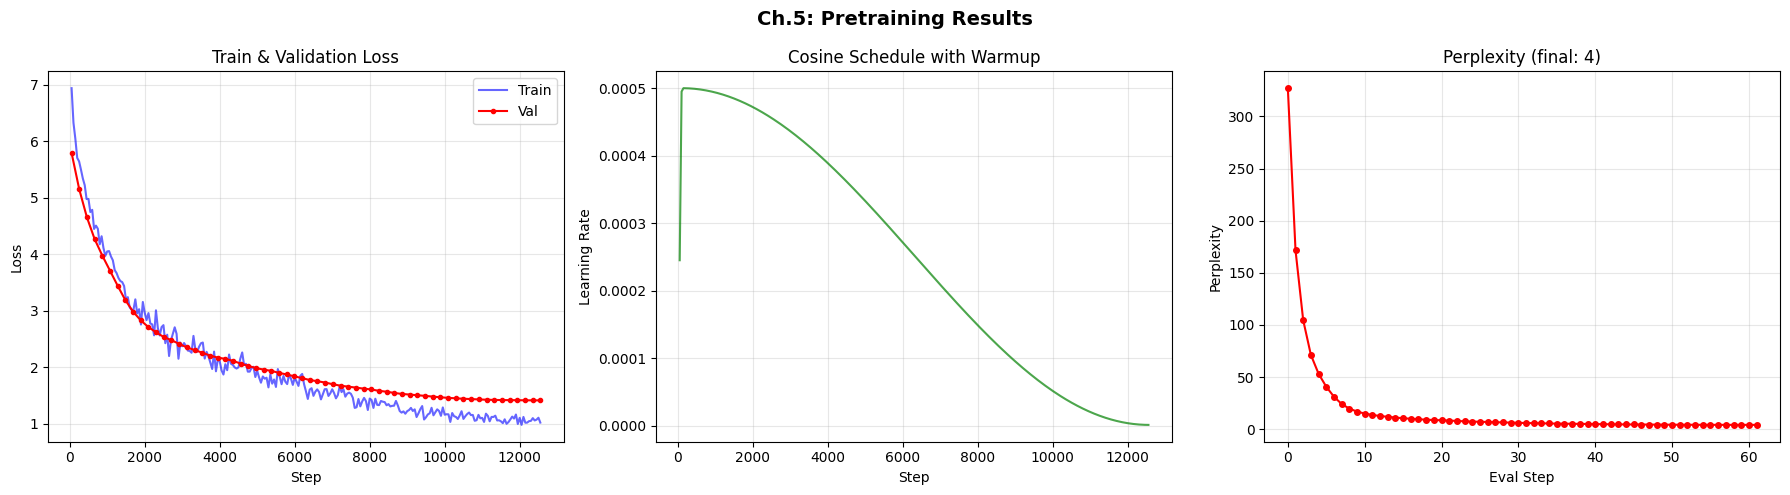


=== Samples Generated During Training ===

Step 300: ؟ ** في الاسبوع؟ ** اذا كان مجموع عدد المار، اذا كان هناك 40 / 4 - 2 = 10 >> 8 = << 4 + 5 * 10 = << 12 >> 18 >> 18 >> 60 × 20 + 6 = 50 + 4 +

Step 600: . كم عدد الاسماك التي تملكها ماري في كل طالب في كل قطعه من كل قطعه من الحليب؟ بكم عدد الاسماك في رحله تلاحظات في كل شهر خلال طالب لان 40 / 2 = << 40 / 2 = 2 >> 8. كم عدد الالعاب التي شاهد

Step 900: في حفل التخفيه. ما مجموعه الرخت من السبوا. في هذه الرتار. اذا كان عدد الاقق الذين يتقن في حفل التخت الذين يقطوا في حفل المتبعد. كم عدد ال

Step 1200: ين: 4 ارانب / شخص * 4 اطارات = << 4 * 4 = 8 >> 8 هكرين. يبلغ مجموع اقاه الاجمالي للمساعده 10 افضلين في متبقييه + 10 مهمه + 2 مجلس =

Step 1500: يه هي 20 % من اجمالي المال للمقاعه. اذا كان سعر الاجهزهيه منحه هي 3 دولارات، فكم تبلغ قيمه الاشريه؟ كم تبلغ قيمه الايرادات المباع؟ ** تبلغ تكلفه الاجهزه هي 3 * 20 =$<< 3 * 20

Step 1800: . #### 5 في يوم الاثنين، يوم الثلاثاء هناك 7 ايام في الاسبوع. اذا كان متوسط عدد الساعات في الاسبوع السابق هو 7 ايا

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(history['step'][:len(history['train_loss'])], history['train_loss'], 'b-', alpha=0.6, label='Train')
if history['val_loss']:
    val_x = np.linspace(history['step'][0], history['step'][-1], len(history['val_loss']))
    axes[0].plot(val_x, history['val_loss'], 'r-o', markersize=3, label='Val')
axes[0].set_xlabel('Step'); axes[0].set_ylabel('Loss')
axes[0].set_title('Train & Validation Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(history['step'][:len(history['lr'])], history['lr'], 'g-', alpha=0.7)
axes[1].set_xlabel('Step'); axes[1].set_ylabel('Learning Rate')
axes[1].set_title('Cosine Schedule with Warmup'); axes[1].grid(True, alpha=0.3)
if history['val_loss']:
    ppls = [math.exp(l) for l in history['val_loss']]
    axes[2].plot(ppls, 'r-o', markersize=4)
    axes[2].set_xlabel('Eval Step'); axes[2].set_ylabel('Perplexity')
    axes[2].set_title(f'Perplexity (final: {ppls[-1]:.0f})'); axes[2].grid(True, alpha=0.3)
plt.suptitle('Ch.5: Pretraining Results', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print('\n=== Samples Generated During Training ===')
for s in history['samples']:
    print(f"\nStep {s['step']}: {s['text'][:200]}")

In [19]:
test_prompts = ['اذا كان لدى احمد', 'كم عدد', 'حل المساله']
print('=== Pretrained Model Generation ===')
for prompt in test_prompts:
    prompt_ids = tokenizer.encode(prompt)
    gen = generate(model, torch.tensor([prompt_ids], device=DEVICE),
                   max_new_tokens=60, context_length=CONTEXT_LENGTH, temperature=0.8, top_k=25)
    print(f'\nPrompt: {prompt}')
    print(f'Output: {tokenizer.decode(gen[0].tolist()[len(prompt_ids):])}')
    print('-' * 60)

=== Pretrained Model Generation ===

Prompt: اذا كان لدى احمد
Output: 10 احمد، فكم عدد احمد التي يمتلكها احمد الان؟ كم احمد امسك به احمد؟ ** احمد امسك بـ 3 احمد اكثر من احمد التي امسك بها في البدايه، اي احمد التي امسك بها احمد التي امسك بها احمد
------------------------------------------------------------

Prompt: كم عدد
Output: الساعات التي عملها جون في المجمل؟ ** لذا فقد عمل لمده 60 / 2 = << 60 / 2 = 30 >> 30 ساعه. كم عدد الساعات التي يعملها جون في الاسبوع؟ ** لذا فهو يعمل لمده 30 * 5 = << 30 * 5 = 150 >> 150 ساعه. كم عدد الساعات التي عملها جون في
------------------------------------------------------------

Prompt: حل المساله
Output: الرياضيه. كم عدد الدقائق التي يقضيها ويليام في حفله عيد ميلاد ساره؟ ** يقضي ويليام 4 + 2 =<< 4 + 2 = 6 >> 6 دقائق في حفله ساره. كم عدد الدقائق التي يقضيها ويليام في حفله ساره؟ ** يقضي ويليام 10 + 6 =<< 10 + 6 = 16 >> 16
------------------------------------------------------------


---
# Chapter 6 — Fine-Tuning for Classification

> **Transfer learning:** We take the pretrained model and add a new classification head.
> **Freezing:** We freeze most layers and only train the last block + classification head.

---

In [20]:
class GPTClassifier(nn.Module):
    def __init__(self, base_model, num_classes, freeze_base=True):
        super().__init__()
        self.base = deepcopy(base_model)
        emb_dim = base_model.cfg['emb_dim']
        if freeze_base:
            for p in self.base.parameters(): p.requires_grad = False
            for p in self.base.trf_blocks[-1].parameters(): p.requires_grad = True
            for p in self.base.final_norm.parameters(): p.requires_grad = True
        self.head = nn.Sequential(nn.Linear(emb_dim, emb_dim), nn.GELU(), nn.Dropout(0.1), nn.Linear(emb_dim, num_classes))
    def forward(self, idx):
        B, T = idx.shape
        x = self.base.drop_emb(self.base.tok_emb(idx) + self.base.pos_emb(torch.arange(T, device=idx.device)))
        for block in self.base.trf_blocks: x = block(x)
        return self.head(self.base.final_norm(x)[:, -1, :])

classifier = GPTClassifier(model, num_classes=3, freeze_base=True)
total_p = sum(p.numel() for p in classifier.parameters())
train_p = sum(p.numel() for p in classifier.parameters() if p.requires_grad)
print(f'Total parameters:     {total_p:,}')
print(f'Trainable parameters: {train_p:,}')
print(f'Frozen parameters:    {total_p - train_p:,}')
print(f'Trainable ratio:      {train_p/total_p:.1%}')
print(f'\n✔ Only last block + classification head are trainable = transfer learning')
del classifier

Total parameters:     21,858,307
Trainable parameters: 3,415,555
Frozen parameters:    18,442,752
Trainable ratio:      15.6%

✔ Only last block + classification head are trainable = transfer learning


---
# Chapter 7 — Fine-Tuning to Follow Instructions (SFT)

> **Loss masking:** The loss is computed only on the **answer** tokens, not on the instructions.
>
> ```
> <|bos|> Solve the problem... \n Question <|eos|> <|bos|> Answer <|eos|>
> │──── masked (no loss) ────────────┤│── loss computed ──┤
> ```
> This teaches the model to generate only the solution, without memorizing the instructions.

---

## Step 7.1 — Visualize Loss Masking

Preparing 17,584 SFT samples...


SFT data:   0%|          | 0/17584 [00:00<?, ?it/s]

SFT dataset: 17,584 samples  (train: 15826 | val: 1758)


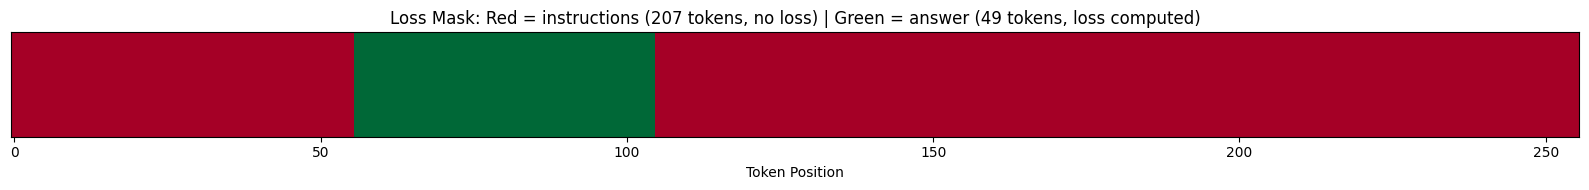

In [21]:
sft_dataset = SFTDataset(sft_records, tokenizer, CONTEXT_LENGTH)
sft_val_n = max(1, int(0.1 * len(sft_dataset)))
sft_train_n = len(sft_dataset) - sft_val_n
sft_train_ds, sft_val_ds = random_split(sft_dataset, [sft_train_n, sft_val_n])
sft_train_loader = DataLoader(sft_train_ds, batch_size=8, shuffle=True, drop_last=True)
sft_val_loader   = DataLoader(sft_val_ds,   batch_size=8, shuffle=False, drop_last=False)
print(f'SFT dataset: {len(sft_dataset):,} samples  (train: {sft_train_n} | val: {sft_val_n})')

inp, tgt, mask = sft_dataset[0]
fig, ax = plt.subplots(figsize=(16, 2))
ax.imshow(mask.numpy().reshape(1, -1), cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
ax.set_xlabel('Token Position'); ax.set_yticks([])
ax.set_title(f'Loss Mask: Red = instructions ({(mask==0).sum().item()} tokens, no loss) | Green = answer ({(mask==1).sum().item()} tokens, loss computed)', fontsize=12)
plt.tight_layout(); plt.show()

## Step 7.2 — Run Supervised Fine-Tuning (SFT)

> I fine-tuned the model on math problems with loss masking.

In [22]:
SFT_EPOCHS, SFT_LR = 5, 2e-5
sft_optimizer = torch.optim.AdamW(model.parameters(), lr=SFT_LR, weight_decay=0.01)
sft_history = {'train_loss': [], 'val_loss': [], 'samples': []}
model.train(); t0 = time.time()

print(f'\nSFT Fine-tuning — {SFT_EPOCHS} epochs\n')
for epoch in range(SFT_EPOCHS):
    pbar = tqdm(sft_train_loader, desc=f'SFT Epoch {epoch+1}/{SFT_EPOCHS}', leave=True)
    epoch_loss = 0
    for inp, tgt, mask in pbar:
        inp, tgt, mask = inp.to(DEVICE), tgt.to(DEVICE), mask.to(DEVICE)
        logits = model(inp)
        B, T, V = logits.shape
        ptl = nn.functional.cross_entropy(logits.view(B*T, V), tgt.view(B*T), reduction='none')
        loss = (ptl * mask.view(B*T)).sum() / mask.sum().clamp(min=1)
        sft_optimizer.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0); sft_optimizer.step()
        epoch_loss += loss.item(); pbar.set_postfix(loss=f'{loss.item():.4f}')

    sft_history['train_loss'].append(epoch_loss / len(sft_train_loader))
    model.eval()
    vl_t, vl_n = 0, 0
    with torch.no_grad():
        for inp, tgt, mask in sft_val_loader:
            inp, tgt, mask = inp.to(DEVICE), tgt.to(DEVICE), mask.to(DEVICE)
            logits = model(inp); B,T,V = logits.shape
            ptl = nn.functional.cross_entropy(logits.view(B*T,V), tgt.view(B*T), reduction='none')
            vl_t += (ptl * mask.view(B*T)).sum().item() / mask.sum().clamp(min=1).item(); vl_n += 1
    sft_history['val_loss'].append(vl_t / max(vl_n, 1))

    prompt = 'حل المساله الرياضيه التاليه خطوه بخطوه.\nاذا كان لدى احمد 5 تفاحات واعطى 2 لصديقه، كم تبقى؟'
    prompt_ids = tokenizer.encode(prompt)
    gen = generate(model, torch.tensor([prompt_ids], device=DEVICE),
                   max_new_tokens=80, context_length=CONTEXT_LENGTH, temperature=0.7, top_k=25)
    txt = tokenizer.decode(gen[0].tolist()[len(prompt_ids):])
    sft_history['samples'].append({'epoch': epoch+1, 'text': txt})
    print(f'  Epoch {epoch+1} | train: {sft_history["train_loss"][-1]:.4f} | val: {sft_history["val_loss"][-1]:.4f}')
    print(f'  ✍️  {txt[:150]}'); model.train()

torch.save({'model_state_dict': model.state_dict(), 'config': GPT_CONFIG}, FINAL_SFT_PATH)
with open(SFT_SAMPLES_PATH, 'w', encoding='utf-8') as f:
    json.dump(sft_history['samples'], f, ensure_ascii=False, indent=2)

print(f'\n✅ SFT done in {time.time()-t0:.0f}s')
print(f'Saved SFT checkpoint:   {FINAL_SFT_PATH}')
print(f'Saved SFT samples JSON: {SFT_SAMPLES_PATH}')


SFT Fine-tuning — 5 epochs



SFT Epoch 1/5:   0%|          | 0/1978 [00:00<?, ?it/s]

  Epoch 1 | train: 0.7835 | val: 0.6106
  ✍️  كم عدد التفاحات التي يمتلكها احمد؟ ** يمتلك احمد 5 + 2 = << 5 + 2 = 7 >> 7 تفاحات. كم عدد التفاحات التي حصلت عليها احمد؟ ** عندما احتفظ احمد احمد من ا


SFT Epoch 2/5:   0%|          | 0/1978 [00:00<?, ?it/s]

  Epoch 2 | train: 0.7182 | val: 0.6125
  ✍️  كم عدد التفاحات التي اعطاها احمد؟ ** اعطى احمد 5 + 2 = << 5 + 2 = 7 >> 7 تفاحات. كم عدد التفاحات المتبقيه لدى احمد؟ ** تبقى لدى احمد 5 - 7 = << 5 - 7 


...

  Epoch 3 | train: 0.6771 | val: 0.6169
  ✍️  كم عدد التفاحات التي اعطاها احمد؟ ** اعطى احمد 5 + 2 = 5 تفاحات. كم عدد التفاحات التي اعطاها احمد لاند؟ ** اعطى احمد 5 + 2 = 5 تفاحات. كم عدد التفاحات


SFT Epoch 4/5:   0%|          | 0/1978 [00:00<?, ?it/s]

  Epoch 4 | train: 0.6431 | val: 0.6222
  ✍️  كم عدد التفاحات التي اعطتها حمد؟ ** اعطت حمد ضعف عدد التفاحات التي اعطتها حمد، مما يعني انها اعطتها 2 * 2 = << 2 * 2 = 4 >> 4 تفاحات. كم عدد التفاحات 


SFT Epoch 5/5:   0%|          | 0/1978 [00:00<?, ?it/s]

  Epoch 5 | train: 0.6138 | val: 0.6301
  ✍️  كم عدد التفاحات التي يملكها احمد؟ ** يملك احمد 5 + 2 = << 5 + 2 = 7 >> 7 تفاحات. كم عدد التفاحات التي يملكها احمد؟ ** وبالتالي، يملك احمد ما مجموعه 5 

✅ SFT done in 1496s
Saved SFT checkpoint:   /content/checkpoints/finetuned/best_sft.pt
Saved SFT samples JSON: /content/results/sample_generations/sft_samples.json


## Visualize: Fine-Tuning Results & Final Generation

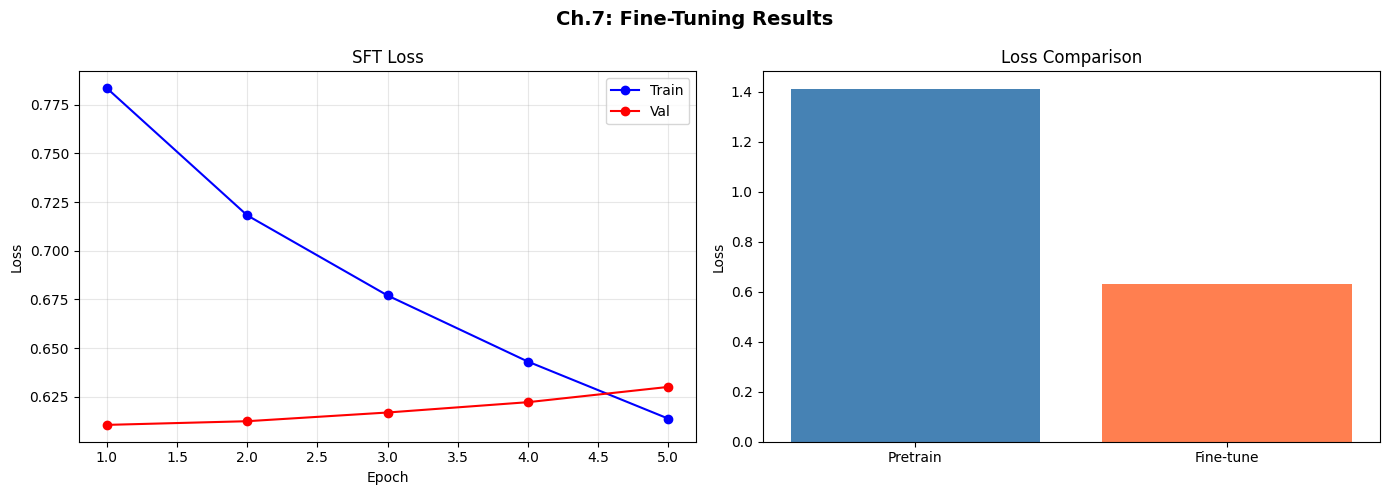

=== Final Model: Arabic Math Reasoning ===

❓ اذا كان لدى ساره 12 كتابا واعطت 4 لصديقتها، كم كتابا تبقى لديها؟
✅ كم كتابا اعطت ساره لصديقتها؟ ** المبلغ الاجمالي الذي اعطته ساره لصديقتها، هو 12 + 4 = 16 كتابا. كم كتابا اعطتها ساره لصديقتها؟ ** اعطت ساره لصديقتها، 16 - 4 = 12 كتابا. #### 12 كم يوما ستدوم كيس رقائق البطاطس الذي يزن 30 كيلوغراما؟ ** تدوم كيس رقائق البطاطس الذي يزن 30 كيلوغراما يوميا، اي 30 × 7 ايام. كم اسبوعا ستدوم كيس رقائق البطاطس الذي يزن 30 كيلوغراما؟ ** ستدوم كيس رقائق البطاطس
────────────────────────────────────────────────────────────

❓ اشترى احمد 3 اقلام بسعر 5 ريالات للقلم. كم دفع اجمالا؟
✅ تكلف الاقلام 3 x 5 دولار = 15 دولار. اشترى 3 * 5 = 15 قلم رصاص. #### 15 بالنسبه لكل سنه، تبلغ من العمر خمسه اعوام، سيكون ماكس ثمانيه اعوام. بعد كم سنه سيكون ماكس بعد 8 اعوام؟ بعد 5 سنوات، سيكون ماكس قد يبلغ من العمر 9 + 5 = << 9 + 5 = 14 >> 14 سنه. بعد 8 اعوام سيكون ماكس 14 + 8 = << 14 + 8 = 24 >> 24 سنه. بعد 8 اعوام سيكون ماكس 24 ÷ 2 =
────────────────────────────────────────

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ex = range(1, SFT_EPOCHS + 1)
axes[0].plot(ex, sft_history['train_loss'], 'b-o', label='Train'); axes[0].plot(ex, sft_history['val_loss'], 'r-o', label='Val')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].set_title('SFT Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].bar(['Pretrain', 'Fine-tune'], [best_val, sft_history['val_loss'][-1]], color=['steelblue', 'coral'])
axes[1].set_ylabel('Loss'); axes[1].set_title('Loss Comparison')
plt.suptitle('Ch.7: Fine-Tuning Results', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

math_questions = [
    'اذا كان لدى ساره 12 كتابا واعطت 4 لصديقتها، كم كتابا تبقى لديها؟',
    'اشترى احمد 3 اقلام بسعر 5 ريالات للقلم. كم دفع اجمالا؟',
    'اذا كان عمر خالد 15 سنه وعمر اخيه ضعف عمره، فكم عمر اخيه؟',
]
print('=== Final Model: Arabic Math Reasoning ===')
for q in math_questions:
    prompt = f'حل المساله الرياضيه التاليه خطوه بخطوه.\n{q}'
    prompt_ids = tokenizer.encode(prompt)
    gen = generate(model, torch.tensor([prompt_ids], device=DEVICE),
                   max_new_tokens=100, context_length=CONTEXT_LENGTH, temperature=0.7, top_k=25)
    print(f'\n❓ {q}')
    print(f'✅ {tokenizer.decode(gen[0].tolist()[len(prompt_ids):])}')
    print('─' * 60)

---
# Evaluation & Error Analysis

> We measure model performance using **Perplexity** and **Answer Accuracy**, and classify error types.

---

In [24]:
ARABIC_DIGITS = str.maketrans('٠١٢٣٤٥٦٧٨٩', '0123456789')
def extract_number(text):
    text = text.translate(ARABIC_DIGITS)
    nums = re.findall(r'-?\d+\.?\d*', text)
    return float(nums[-1]) if nums else None

model.eval()
total_loss, total_tok = 0.0, 0
with torch.no_grad():
    for inp, tgt in val_loader:
        inp, tgt = inp.to(DEVICE), tgt.to(DEVICE)
        logits = model(inp)
        total_loss += nn.functional.cross_entropy(logits.view(-1, logits.size(-1)), tgt.view(-1), reduction='sum').item()
        total_tok += tgt.numel()
ppl = math.exp(total_loss / total_tok)
print(f'Perplexity: {ppl:.2f}')

NUM_EVAL = min(50, len(sft_records))
correct, results = 0, []
for rec in tqdm(sft_records[:NUM_EVAL], desc='Evaluating'):
    prompt = f"{rec['instruction']}\n{rec['input']}"
    prompt_ids = tokenizer.encode(prompt)
    gen = generate(model, torch.tensor([prompt_ids], device=DEVICE),
                   max_new_tokens=100, context_length=CONTEXT_LENGTH, temperature=0.3, top_k=10)
    gen_text = tokenizer.decode(gen[0].tolist()[len(prompt_ids):])
    pred, gold = extract_number(gen_text), extract_number(rec['output'])
    ok = pred is not None and gold is not None and abs(pred - gold) < 1e-6
    if ok: correct += 1
    results.append({'q': rec['input'][:80], 'gold': gold, 'pred': pred, 'ok': ok, 'gen': gen_text[:100]})
accuracy = correct / NUM_EVAL
print(f'Answer accuracy: {accuracy:.2%} ({correct}/{NUM_EVAL})')

Perplexity: 4.26


Evaluating:   0%|          | 0/50 [00:00<?, ?it/s]

Answer accuracy: 8.00% (4/50)


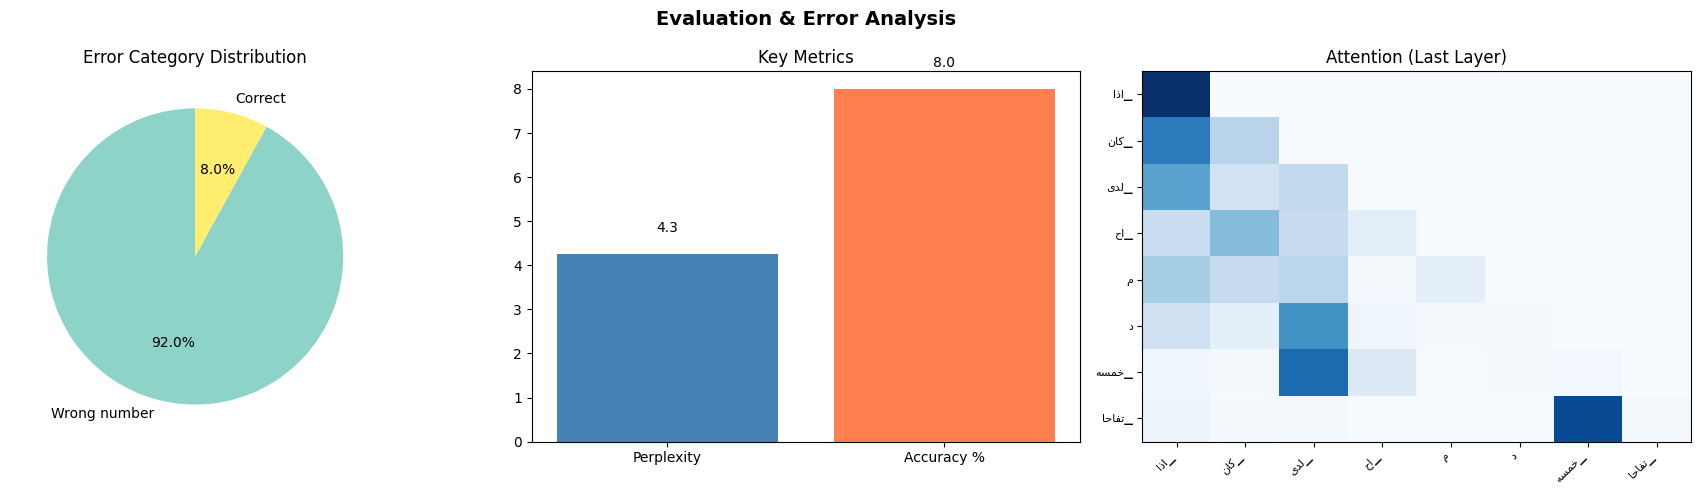


=== Sample Results ===
❌ س: باعت نتاليا مشابك إلى 48 من أصدقائها في شهر أبريل، ثم باعت نصف ذلك العدد من المش
   Gold: 72.0 | Pred: 140.0
   Output: باعت نتاليا 48 / 2 = << 48 / 2 = 24 >> 24 مشبكا في شهر مايو. باعت نتاليا 24 / 2 = << 24 / 2 = 12 >> 

❌ س: تحصل ويندي على 12 دولار في الساعة مقابل رعاية الأطفال. بالأمس، اعتنت بالأطفال لم
   Gold: 10.0 | Pred: 3000.0
   Output: كم دقيقه ربحت وندي في رعايه الاطفال؟ ** ربحت وندي 12 * 50 = 300 دولار في الساعه. كم دقيقه ربحت وندي 

❌ س: توفّر بيتي المال لحقيبة يد جديدة تكلفتها 100$. بيتي لديها فقط نصف المبلغ الذي تح
   Gold: 5.0 | Pred: 100.0
   Output: كم من المال تحتاج بيتي لتنفقه على شراء الحقيبه؟ ** تحتاج بيتي لتنفقه نصف المبلغ الذي تحتاجه على شراء

❌ س: تقرأ جولي كتاباً مؤلفاً من 120 صفحة. بالأمس، تمكنت من قراءة 12 صفحة، واليوم قرأت
   Gold: 42.0 | Pred: 100.0
   Output: كم صفحه قراتها جولي اليوم؟ ** حتى الان، قرات جولي 120 + 12 = << 120 + 12 = 108 >> 108 صفحه. كم صفحه 

❌ س: يكتب جيمس رسالة من 3 صفحات إلى صديقين مختلفين مرتين في الأسبوع.

In [25]:
categories = Counter()
for r in results:
    if r['ok']: categories['Correct'] += 1
    elif r['pred'] is None:
        if len(r['gen'].strip()) < 20: categories['Too short'] += 1
        else:
            words = r['gen'].split()
            if len(words)>5 and len(set(words))/len(words)<0.5: categories['Repetition'] += 1
            else: categories['No number'] += 1
    else: categories['Wrong number'] += 1

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
labels, sizes = zip(*categories.items()) if categories else (['None'], [1])
axes[0].pie(sizes, labels=labels, colors=plt.cm.Set3(np.linspace(0,1,len(labels))), autopct='%1.1f%%', startangle=90)
axes[0].set_title('Error Category Distribution')
metrics = {'Perplexity': ppl, 'Accuracy %': accuracy*100}
axes[1].bar(metrics.keys(), metrics.values(), color=['steelblue', 'coral'])
axes[1].set_title('Key Metrics')
for i, (k,v) in enumerate(metrics.items()): axes[1].text(i, v+0.5, f'{v:.1f}', ha='center')

viz_text = 'اذا كان لدى احمد خمسه تفاحات'
viz_ids = tokenizer.encode(viz_text)
with torch.no_grad(): _, amaps = model(torch.tensor([viz_ids], device=DEVICE), return_attention=True)
det = tokenizer.get_token_details(viz_text)
lbl = [ar_text(d['token'][:6]) for d in det][:amaps[-1].shape[-1]]
attn = amaps[-1][0, 0, :len(lbl), :len(lbl)].cpu().numpy()
axes[2].imshow(attn, cmap='Blues', aspect='auto')
axes[2].set_xticks(range(len(lbl))); axes[2].set_xticklabels(lbl, rotation=45, ha='right', fontsize=8)
axes[2].set_yticks(range(len(lbl))); axes[2].set_yticklabels(lbl, fontsize=8)
axes[2].set_title('Attention (Last Layer)')
plt.suptitle('Evaluation & Error Analysis', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print('\n=== Sample Results ===')
for r in results[:5]:
    s = '✅' if r['ok'] else '❌'
    print(f"{s} س: {r['q']}")
    print(f"   Gold: {r['gold']} | Pred: {r['pred']}")
    print(f"   Output: {r['gen']}\n")

## Visualize: Token-by-Token Generation

> Let's see how the model chooses each token and what the top-5 alternatives are at each step.

In [26]:
prompt = 'اذا كان لديك'
ids = tokenizer.encode(prompt)
inp = torch.tensor([ids], device=DEVICE)
print(f'Prompt: "{prompt}"\n')
print(f'{"Step":<8} {"Token":<15} {"ID":<8} {"Prob":<10} {"Top-5 alternatives"}')
print('─' * 80)

model.eval()
with torch.no_grad():
    for step in range(15):
        idx_cond = inp[:, -CONTEXT_LENGTH:]
        logits = model(idx_cond)[:, -1, :] / 0.8
        tv, _ = torch.topk(logits, 25)
        logits = torch.where(logits < tv[:, -1:], torch.full_like(logits, float('-inf')), logits)
        probs = torch.softmax(logits, dim=-1)
        nt = torch.multinomial(probs, 1)
        t5p, t5i = torch.topk(probs, 5)
        tok_str = tokenizer.inverse_vocab.get(nt.item(), '?')
        cands = ', '.join(f"{tokenizer.inverse_vocab.get(i.item(),'?')}({p.item():.2f})" for i, p in zip(t5i[0], t5p[0]))
        print(f'{step:<8} {tok_str:<15} {nt.item():<8} {probs[0,nt.item()].item():<10.4f} {cands}')
        inp = torch.cat([inp, nt], dim=-1)

print(f'\nFull output: {tokenizer.decode(inp[0].tolist())}')

Prompt: "اذا كان لديك"

Step     Token           ID       Prob       Top-5 alternatives
────────────────────────────────────────────────────────────────────────────────
0        ▁24             328      0.2964     ▁24(0.30), ▁60(0.14), ▁سته(0.06), ▁10(0.06), ▁20(0.05)
1        ▁دجاجه          2606     0.0072     ▁دولارا(0.34), ▁كره(0.16), ▁برتقاله(0.09), ▁كتابا(0.08), ▁قطعه(0.07)
2        ▁في             213      0.8007     ▁في(0.80), ،(0.09), ▁و(0.03), ▁بعد(0.02), ▁قبل(0.01)
3        ▁مزرعته         4640     0.7186     ▁مزرعته(0.72), ▁مزرعه(0.08), ▁مز(0.06), ▁البدايه(0.04), ▁البدايه،(0.03)
4        ،               105      0.9862     ،(0.99), ▁و(0.01), ▁.(0.00), ؟(0.00), ▁الان،(0.00)
5        ▁فكم            358      0.9251     ▁فكم(0.93), ▁فان(0.02), ▁وباع(0.02), ▁ولدى(0.01), ▁اي(0.00)
6        ▁عدد            238      0.9123     ▁عدد(0.91), ▁دجاجه(0.05), ▁من(0.01), ▁بيضه(0.01), ▁سيكون(0.00)
7        ▁الدجاج         1603     0.9882     ▁الدجاج(0.99), ▁الابقار(0.00), ▁الدي(0.00), ▁دجا

---
# Conclusion

## What We Built
- **BPE tokenizer** from scratch for Arabic text
- **Multi-head attention** with causal masking
- **GPT model** (~30M parameters) with weight tying
- **Pretraining** with next-token prediction + cosine schedule
- **Supervised fine-tuning (SFT)** with loss masking for instruction following
- **Evaluation** with perplexity, accuracy, and error analysis

## Key Takeaways
1. BPE handles Arabic effectively by learning subword units
2. Self-attention enables contextual understanding
3. Pretraining learns language patterns without labels
4. Loss masking focuses learning on answer generation only
5. Small models learn patterns but struggle with complex reasoning

## Limitations
- ~30M parameters is too small for complex reasoning
- Only ~8000 training examples
- No RLHF or preference optimization
- Context window limited to 256 tokens

## Future Work
- Scale to 100M+ parameters
- More Arabic pretraining data
- Chain-of-Thought prompting
- RLHF / DPO for alignment

---
# Interactive Demo (Gradio)



---

In [27]:
!pip install -q gradio

In [ ]:
from pathlib import Path
import shutil
from google.colab import files

# Collect all expected artifacts from Colab runtime
artifacts = [
    "/content/data/pretrain/data.txt",
    "/content/data/finetune/sft_data.json",
    "/content/data/tokenizer.json",
    "/content/checkpoints/pretrained/best_pretrained.pt",
    "/content/checkpoints/pretrained/final_pretrained.pt",
    "/content/checkpoints/finetuned/best_sft.pt",
    "/content/results/sample_generations/sft_samples.json",
]

# Build export folder with same structure
export_root = Path("/content/export_artifacts")
if export_root.exists():
    shutil.rmtree(export_root)
export_root.mkdir(parents=True, exist_ok=True)

for src in artifacts:
    p = Path(src)
    if p.exists():
        dst = export_root / p.relative_to("/content")
        dst.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(p, dst)
        print(f"Copied: {p}")
    else:
        print(f"Missing: {p}")

# Zip and download
zip_base = "/content/ArabicLLM_artifacts"
shutil.make_archive(zip_base, "zip", root_dir=export_root)
files.download(zip_base + ".zip")

In [ ]:
import gradio as gr
import io, base64
from PIL import Image

# ──────────────────────────────────────────────────────────
# Helper functions for the demo
# ──────────────────────────────────────────────────────────

def run_full_pipeline(question, temperature, top_k, max_tokens):
    """One-click: tokenize → encode → generate → evaluate — all at once."""
    if not question.strip():
        return ("Enter an Arabic math question above.", None, None, None,
                "", "", "", "")

    prompt = f'حل المساله الرياضيه التاليه خطوه بخطوه.\n{question}'

    # ── Step 1: Tokenize ──
    details = tokenizer.get_token_details(question)
    ids = tokenizer.encode(prompt)

    tok_html = '<div style="display:flex;flex-wrap:wrap;gap:4px;direction:rtl;margin:8px 0;">'
    colors = ['#4F46E5','#059669','#D97706','#DC2626','#7C3AED','#0891B2','#C026D3','#EA580C']
    for i, d in enumerate(details):
        c = colors[i % len(colors)]
        tok_html += (f'<span style="background:{c}22;border:1px solid {c};'
                     f'padding:4px 8px;border-radius:6px;font-size:14px;'
                     f'color:{c};font-weight:600;">{ar_text(d["token"])}'
                     f'<sub style="font-size:10px;opacity:0.7;margin-right:2px;">{d["id"]}</sub></span>')
    tok_html += '</div>'
    tok_info = f'**{len(question)} chars → {len(tokenizer.encode(question))} tokens** (compression: {len(question)/max(len(tokenizer.encode(question)),1):.1f}x)'

    # ── Step 2: Generate ──
    gen = generate(model, torch.tensor([ids], device=DEVICE),
                   max_new_tokens=int(max_tokens), context_length=CONTEXT_LENGTH,
                   temperature=temperature, top_k=int(top_k))
    output = tokenizer.decode(gen[0].tolist()[len(ids):])

    # ── Step 3: Step-by-step generation trace ──
    model.eval()
    inp2 = torch.tensor([ids], device=DEVICE)
    steps_html = '<div style="font-family:monospace;font-size:13px;line-height:2;">'
    with torch.no_grad():
        for s in range(min(15, int(max_tokens))):
            lg = model(inp2[:, -CONTEXT_LENGTH:])[:, -1, :] / max(temperature, 0.1)
            if int(top_k) > 0:
                tv, _ = torch.topk(lg, min(int(top_k), lg.size(-1)))
                lg = torch.where(lg < tv[:, -1:], torch.full_like(lg, float('-inf')), lg)
            pr = torch.softmax(lg, dim=-1)
            nt = torch.multinomial(pr, 1)
            t5p, t5i = torch.topk(pr, 5)
            chosen = ar_text(tokenizer.inverse_vocab.get(nt.item(), '?'))
            prob = pr[0, nt.item()].item()

            bar_w = int(prob * 150)
            bar_color = '#059669' if prob > 0.5 else '#D97706' if prob > 0.2 else '#DC2626'
            alts = ' '.join(f'<span style="background:#f1f5f9;padding:1px 5px;border-radius:3px;font-size:11px;">'
                           f'{ar_text(tokenizer.inverse_vocab.get(idx.item(),"?"))}<sub>{p.item():.0%}</sub></span>'
                           for idx, p in zip(t5i[0], t5p[0]))

            steps_html += (f'<div style="margin:2px 0;display:flex;align-items:center;gap:8px;">'
                          f'<span style="color:#64748b;width:25px;">#{s+1}</span>'
                          f'<span style="background:{bar_color}22;border:1px solid {bar_color};'
                          f'padding:2px 8px;border-radius:4px;font-weight:700;min-width:60px;'
                          f'text-align:center;color:{bar_color};">{chosen}</span>'
                          f'<div style="background:#e2e8f0;border-radius:3px;width:160px;height:14px;">'
                          f'<div style="background:{bar_color};width:{bar_w}px;height:14px;'
                          f'border-radius:3px;"></div></div>'
                          f'<span style="font-size:11px;color:#64748b;">{prob:.1%}</span>'
                          f'<span style="margin-left:10px;">{alts}</span></div>')
            inp2 = torch.cat([inp2, nt], dim=-1)
    steps_html += '</div>'

    # ── Step 4: Attention heatmap ──
    with torch.no_grad():
        _, attn_maps = model(torch.tensor([ids[:20]], device=DEVICE), return_attention=True)
    attn = attn_maps[0][0, 0].cpu().numpy()
    labels = [ar_text(d['token'][:6]) for d in tokenizer.get_token_details(prompt)][:attn.shape[0]]
    n = len(labels)

    fig_attn, ax = plt.subplots(figsize=(7, 5))
    im = ax.imshow(attn[:n, :n], cmap='YlOrRd', aspect='auto')
    ax.set_xticks(range(n)); ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(n)); ax.set_yticklabels(labels, fontsize=8)
    ax.set_title('Attention Weights (Layer 0, Head 0)', fontsize=12)
    fig_attn.colorbar(im, ax=ax, shrink=0.8)
    plt.tight_layout()

    return (tok_html, tok_info, fig_attn, steps_html,
            f'### Generated Answer\n\n{output}',
            f'Prompt tokens: {len(ids)} | Generated tokens: {len(gen[0])-len(ids)}',
            output, f'Vocab: {tokenizer.vocab_size:,} | Model params: {model.count_parameters():,}')


def explore_tokenizer(text):
    """Tokenizer deep-dive with visual breakdown."""
    if not text.strip():
        return "", "", None

    details = tokenizer.get_token_details(text)
    ids = tokenizer.encode(text)
    decoded = tokenizer.decode(ids)

    colors = ['#4F46E5','#059669','#D97706','#DC2626','#7C3AED','#0891B2','#C026D3','#EA580C']
    html = '<div style="direction:rtl;margin:10px 0;">'
    html += '<h4 style="color:#334155;">Token Breakdown</h4>'
    html += '<div style="display:flex;flex-wrap:wrap;gap:6px;margin:10px 0;">'
    for i, d in enumerate(details):
        c = colors[i % len(colors)]
        html += (f'<div style="background:{c}11;border:2px solid {c};padding:8px 14px;'
                f'border-radius:10px;text-align:center;min-width:50px;">'
                f'<div style="font-size:18px;font-weight:700;color:{c};">{ar_text(d["token"])}</div>'
                f'<div style="font-size:10px;color:#94a3b8;margin-top:4px;">ID: {d["id"]}</div>'
                f'<div style="font-size:9px;color:#cbd5e1;">from: {d["word"][:8]}</div>'
                f'</div>')
    html += '</div></div>'

    stats = (f'**Input:** {len(text)} characters\n\n'
             f'**Output:** {len(ids)} tokens\n\n'
             f'**Compression:** {len(text)/max(len(ids),1):.1f}x\n\n'
             f'**Vocab size:** {tokenizer.vocab_size:,}\n\n'
             f'**Decoded:** {decoded}')

    fig, ax = plt.subplots(figsize=(8, 3))
    word_counts = {}
    for d in details:
        w = d['word'][:10]
        word_counts[w] = word_counts.get(w, 0) + 1
    if word_counts:
        bars = ax.barh(list(word_counts.keys()), list(word_counts.values()),
                       color=[colors[i%len(colors)] for i in range(len(word_counts))],
                       edgecolor='white', linewidth=0.5)
        ax.set_xlabel('Tokens per word')
        ax.set_title('Subword Segmentation')
        ax.invert_yaxis()
        for bar, v in zip(bars, word_counts.values()):
            ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                    str(v), va='center', fontsize=10, fontweight='bold')
    plt.tight_layout()

    return html, stats, fig


def explore_attention(text, layer_idx, head_idx):
    """Attention heatmap explorer."""
    if not text.strip():
        return None, ""
    ids = tokenizer.encode(text)[:CONTEXT_LENGTH]
    details = tokenizer.get_token_details(text)
    labels = [ar_text(d['token'][:8]) for d in details][:len(ids)]

    with torch.no_grad():
        _, attn_maps = model(torch.tensor([ids], device=DEVICE), return_attention=True)

    li = min(int(layer_idx), len(attn_maps)-1)
    hi = min(int(head_idx), attn_maps[0].shape[1]-1)
    attn = attn_maps[li][0, hi].cpu().numpy()
    n = min(len(labels), attn.shape[0])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={'width_ratios': [3, 1]})

    im = axes[0].imshow(attn[:n, :n], cmap='YlOrRd', aspect='auto')
    axes[0].set_xticks(range(n)); axes[0].set_xticklabels(labels[:n], rotation=45, ha='right', fontsize=9)
    axes[0].set_yticks(range(n)); axes[0].set_yticklabels(labels[:n], fontsize=9)
    axes[0].set_title(f'Attention Heatmap — Layer {li}, Head {hi}', fontsize=13, fontweight='bold')
    fig.colorbar(im, ax=axes[0], shrink=0.8)

    row_entropy = []
    for r in range(n):
        row = attn[r, :r+1]
        row = row / (row.sum() + 1e-9)
        ent = -sum(p * np.log2(p + 1e-9) for p in row)
        row_entropy.append(ent)

    axes[1].barh(range(n), row_entropy, color='#4F46E5', alpha=0.7)
    axes[1].set_yticks(range(n)); axes[1].set_yticklabels(labels[:n], fontsize=9)
    axes[1].set_xlabel('Entropy (bits)')
    axes[1].set_title('Attention Entropy', fontsize=11)
    axes[1].invert_yaxis()
    plt.tight_layout()

    info = (f'**Model:** {GPT_CONFIG["emb_dim"]}d, {GPT_CONFIG["n_heads"]} heads, '
            f'{GPT_CONFIG["n_layers"]} layers\n\n'
            f'**Tokens:** {n} | **Layer:** {li} | **Head:** {hi}\n\n'
            f'Higher entropy = attention is spread across many tokens.\n'
            f'Lower entropy = attention is focused on fewer tokens.')

    return fig, info


def generate_only(question, temperature, top_k, max_tokens):
    """Quick generation without full pipeline."""
    if not question.strip():
        return "", ""
    prompt = f'حل المساله الرياضيه التاليه خطوه بخطوه.\n{question}'
    ids = tokenizer.encode(prompt)
    gen = generate(model, torch.tensor([ids], device=DEVICE),
                   max_new_tokens=int(max_tokens), context_length=CONTEXT_LENGTH,
                   temperature=temperature, top_k=int(top_k))
    output = tokenizer.decode(gen[0].tolist()[len(ids):])
    return output, f'Prompt: {len(ids)} tokens → Generated: {len(gen[0])-len(ids)} new tokens'


def model_overview():
    """Generate model architecture summary."""
    info = f"""## Model Architecture

| Component | Value |
|-----------|-------|
| Embedding dim | {GPT_CONFIG['emb_dim']} |
| Attention heads | {GPT_CONFIG['n_heads']} |
| Transformer layers | {GPT_CONFIG['n_layers']} |
| Context length | {GPT_CONFIG['context_length']} |
| Vocab size | {tokenizer.vocab_size:,} |
| Total parameters | {model.count_parameters():,} |
| Device | {DEVICE} |
| BPE merges | {len(tokenizer.merges):,} |

### Architecture Diagram
```
Input tokens
    ↓
Token Embedding + Positional Embedding
    ↓
┌─────────────── x{GPT_CONFIG['n_layers']} ───────────────┐
│  Layer Norm → Multi-Head Attention → Residual  │
│  Layer Norm → Feed-Forward (GELU)  → Residual  │
└──────────────────────────────────────────────────┘
    ↓
Layer Norm → Output Head (tied weights)
    ↓
Next-token probabilities
```
"""

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    layer_names = ['Embeddings', 'Attention', 'FFN', 'LayerNorm', 'Output Head']
    param_counts = []
    with torch.no_grad():
        emb_p = sum(p.numel() for n, p in model.named_parameters() if 'emb' in n or 'pos' in n)
        attn_p = sum(p.numel() for n, p in model.named_parameters() if 'attn' in n or 'W_' in n)
        ffn_p = sum(p.numel() for n, p in model.named_parameters() if 'ff' in n)
        ln_p = sum(p.numel() for n, p in model.named_parameters() if 'norm' in n or 'ln' in n)
        out_p = sum(p.numel() for n, p in model.named_parameters() if 'head' in n)
    param_counts = [emb_p, attn_p, ffn_p, ln_p, out_p]
    colors = ['#4F46E5','#059669','#D97706','#DC2626','#7C3AED']

    wedges, texts, autotexts = axes[0].pie(
        param_counts, labels=layer_names, colors=colors,
        autopct='%1.1f%%', startangle=90, textprops={'fontsize': 9})
    axes[0].set_title('Parameter Distribution', fontsize=12, fontweight='bold')

    axes[1].barh(layer_names, [p/1e6 for p in param_counts], color=colors, edgecolor='white')
    axes[1].set_xlabel('Parameters (millions)')
    axes[1].set_title('Parameters by Component', fontsize=12, fontweight='bold')
    axes[1].invert_yaxis()
    for i, v in enumerate(param_counts):
        axes[1].text(v/1e6 + 0.05, i, f'{v/1e6:.2f}M', va='center', fontsize=9, fontweight='bold')

    plt.tight_layout()
    return info, fig


# ──────────────────────────────────────────────────────────
# Build the Gradio App
# ──────────────────────────────────────────────────────────

css = """
.gradio-container { max-width: 1100px !important; }
.gr-button-primary { background: linear-gradient(135deg, #4F46E5, #7C3AED) !important;
                     border: none !important; font-size: 16px !important; }
footer { display: none !important; }
"""

with gr.Blocks(title='Arabic Math LLM Explorer', theme=gr.themes.Soft(
    primary_hue='indigo', secondary_hue='purple', neutral_hue='slate'),
    css=css) as demo:

    gr.Markdown("""
# Arabic Math Reasoning LLM — Interactive Explorer
### Built from scratch following Sebastian Raschka's book | Trained on Arabic-gsm8k-v2

---
""")

    # ════════════════════════════════════════════════════════
    # TAB 1: ONE-CLICK FULL PIPELINE
    # ════════════════════════════════════════════════════════
    with gr.Tab("🚀 One-Click Pipeline", id="pipeline"):
        gr.Markdown("**Enter an Arabic math question and click the button to see the entire pipeline: tokenization → attention → generation → step-by-step trace.**")
        with gr.Row():
            with gr.Column(scale=3):
                q_input = gr.Textbox(
                    label="Arabic Math Question",
                    value="اذا كان لدى ساره 12 كتابا واعطت 4 لصديقتها، كم كتابا تبقى لدى ساره؟",
                    lines=2, rtl=True, placeholder="Type an Arabic math question...")
            with gr.Column(scale=1):
                temp = gr.Slider(0.1, 2.0, 0.7, step=0.1, label="Temperature")
                topk = gr.Slider(1, 100, 25, step=1, label="Top-K")
                maxt = gr.Slider(10, 200, 80, step=10, label="Max Tokens")

        run_btn = gr.Button("🚀 Run Full Pipeline", variant="primary", size="lg")

        model_stats = gr.Markdown()
        with gr.Row():
            with gr.Column():
                gr.Markdown("### 1. Tokenization")
                tok_viz = gr.HTML()
                tok_stats = gr.Markdown()
            with gr.Column():
                gr.Markdown("### 2. Attention Pattern")
                attn_plot = gr.Plot()

        with gr.Row():
            with gr.Column():
                gr.Markdown("### 3. Generated Answer")
                answer_md = gr.Markdown()
                gen_stats = gr.Markdown()
                raw_output = gr.Textbox(label="Raw Output", rtl=True, lines=3)
            with gr.Column():
                gr.Markdown("### 4. Token-by-Token Generation Trace")
                steps_viz = gr.HTML()

        run_btn.click(
            run_full_pipeline, [q_input, temp, topk, maxt],
            [tok_viz, tok_stats, attn_plot, steps_viz, answer_md, gen_stats, raw_output, model_stats])

    # ════════════════════════════════════════════════════════
    # TAB 2: TOKENIZER EXPLORER
    # ════════════════════════════════════════════════════════
    with gr.Tab("🔤 Tokenizer Explorer", id="tokenizer"):
        gr.Markdown("**Explore how the BPE tokenizer splits Arabic text into subword tokens.**")
        tok_input = gr.Textbox(
            label="Arabic Text",
            value="كم عدد التفاحات المتبقية اذا كان لديك عشرة واعطيت ثلاثة؟",
            lines=2, rtl=True)
        tok_btn = gr.Button("🔍 Analyze Tokens", variant="primary")
        with gr.Row():
            tok_html_out = gr.HTML()
        with gr.Row():
            with gr.Column():
                tok_stats_out = gr.Markdown()
            with gr.Column():
                tok_chart = gr.Plot()
        tok_btn.click(explore_tokenizer, tok_input, [tok_html_out, tok_stats_out, tok_chart])

    # ════════════════════════════════════════════════════════
    # TAB 3: ATTENTION EXPLORER
    # ════════════════════════════════════════════════════════
    with gr.Tab("🧠 Attention Explorer", id="attention"):
        gr.Markdown("**Visualize attention patterns across layers and heads. See which tokens attend to which.**")
        with gr.Row():
            attn_input = gr.Textbox(label="Arabic Text", value="اذا كان لدى احمد خمسه تفاحات", lines=2, rtl=True)
            attn_layer = gr.Slider(0, GPT_CONFIG['n_layers']-1, 0, step=1, label="Layer")
            attn_head = gr.Slider(0, GPT_CONFIG['n_heads']-1, 0, step=1, label="Head")
        attn_btn = gr.Button("🧠 Show Attention", variant="primary")
        attn_fig = gr.Plot()
        attn_info = gr.Markdown()
        attn_btn.click(explore_attention, [attn_input, attn_layer, attn_head], [attn_fig, attn_info])

    # ════════════════════════════════════════════════════════
    # TAB 4: QUICK GENERATE
    # ════════════════════════════════════════════════════════
    with gr.Tab("✨ Quick Generate", id="generate"):
        gr.Markdown("**Quickly generate answers to Arabic math questions.**")
        gen_input = gr.Textbox(
            label="Math Question",
            value="اشترى محمد 5 اقلام بسعر 3 ريالات للقلم الواحد، كم دفع؟",
            lines=2, rtl=True)
        with gr.Row():
            gen_temp = gr.Slider(0.1, 2.0, 0.7, step=0.1, label="Temperature")
            gen_topk = gr.Slider(1, 100, 25, step=1, label="Top-K")
            gen_maxt = gr.Slider(10, 200, 100, step=10, label="Max Tokens")
        gen_btn = gr.Button("✨ Generate", variant="primary")
        gen_output = gr.Textbox(label="Generated Answer", rtl=True, lines=5)
        gen_info = gr.Markdown()
        gen_btn.click(generate_only, [gen_input, gen_temp, gen_topk, gen_maxt], [gen_output, gen_info])

        gr.Markdown("### Try These Examples")
        gr.Examples(
            examples=[
                ["اذا كان لدى احمد 10 تفاحات واكل 3، كم تبقى؟"],
                ["اشترت فاطمه 4 دفاتر بسعر 7 ريالات للدفتر، كم دفعت؟"],
                ["كان في الصف 30 طالبا، غاب 5 منهم. كم طالبا حضر؟"],
                ["اذا كان عمر سعد 12 سنه وعمر اخيه ضعف عمره، كم عمر اخيه؟"],
            ],
            inputs=gen_input)

    # ════════════════════════════════════════════════════════
    # TAB 5: MODEL ARCHITECTURE
    # ════════════════════════════════════════════════════════
    with gr.Tab("🏗️ Model Architecture", id="architecture"):
        arch_btn = gr.Button("📊 Show Architecture Details", variant="primary")
        arch_info = gr.Markdown()
        arch_plot = gr.Plot()
        arch_btn.click(model_overview, [], [arch_info, arch_plot])

    gr.Markdown("---\n*Built from scratch following \"Build a Large Language Model (From Scratch)\" by Sebastian Raschka*")

print('Launching interactive demo...')
demo.queue()
app, local_url, share_url = demo.launch(
    share=True,
    inline=True,
    inbrowser=False,
    debug=False,
    show_error=True,
    prevent_thread_lock=True
)
print(f'Local URL: {local_url}')
print(f'Share URL: {share_url}')

/tmp/ipykernel_1058/903799493.py:275: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(title='Arabic Math LLM Explorer', theme=gr.themes.Soft(
/tmp/ipykernel_1058/903799493.py:275: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(title='Arabic Math LLM Explorer', theme=gr.themes.Soft(


Launching interactive demo...
Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://a068f488a65da05938.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


######  *Done by Taif Almezani* 
